# TFG Diego García — Transformación y preparación de predictores tradicionales

Este notebook desarrolla la etapa de transformación del conjunto consolidado de partidos ATP generado previamente. A partir de `atp_matches_2008_2019_2021_2024_full.csv`, los registros se depuran y se transforman desde una estructura partido a una estructura **jugador–partido**.

En esta etapa se construye la variable objetivo `porcentaje_juegos_ganados`, se preparan y codifican los predictores tradicionales y se realiza su análisis y selección utilizando exclusivamente la muestra de desarrollo cuando corresponde.

El resultado se exporta como `df_jugador_actual.csv`, que será sometido posteriormente a las comprobaciones específicas de calidad e integridad antes de construir las variables de carga competitiva.

## 0. Librerías necesarias

En este bloque se importan las librerías que se van a utilizar durante la preparación de datos.

- `numpy`: operaciones numéricas y creación de variables condicionales.
- `pandas`: carga, limpieza y transformación de tablas.
- `matplotlib` y `seaborn`: visualización de datos.

In [1]:
# Importa NumPy para trabajar con operaciones numéricas y condiciones vectorizadas.
import numpy as np

# Importa pandas para cargar, manipular y transformar datasets en formato tabla.
import pandas as pd

# Importa matplotlib para crear gráficos básicos.
import matplotlib.pyplot as plt

# Importa seaborn para crear visualizaciones estadísticas más claras.
import seaborn as sns

## 1. Carga del conjunto consolidado

Se carga el archivo consolidado generado en la etapa anterior, que contiene los partidos ATP de las temporadas utilizadas en el proyecto junto con los indicadores que identifican su función temporal.

Este conjunto constituye la entrada de la transformación a estructura jugador–partido.

In [2]:
file_path = "atp_matches_2008_2019_2021_2024_full.csv"

data = pd.read_csv(
    file_path,
    low_memory=False
)

### 1.1. Comprobación del dataset correcto

In [3]:
columnas_control_temporal = [
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal"
]

assert set(columnas_control_temporal).issubset(data.columns)

display(
    data.groupby(
        [
            "match_year",
            "es_buffer_carga",
            "es_desarrollo_modelo",
            "es_validacion_temporal",
            "es_muestra_estudio"
        ]
    )
    .size()
    .rename("partidos")
    .to_frame()
)

,,,,,partidos
match_year,es_buffer_carga,es_desarrollo_modelo,es_validacion_temporal,es_muestra_estudio,
2008,1,0,0,0,3123
2009,0,1,0,1,3085
2010,0,1,0,1,3030
2011,0,1,0,1,3015
2012,0,1,0,1,3009
2013,0,1,0,1,2944
2014,0,1,0,1,2901
2015,0,1,0,1,2943
2016,0,1,0,1,2941


## 2. Copia de trabajo

Se crea una copia del dataset original para poder trabajar sin modificar directamente la base inicial. Esto es una buena práctica porque permite volver al dataset bruto si algo sale mal.

In [4]:
# Crea una copia del dataset original para trabajar de forma segura.
df = data.copy()

# Muestra las dimensiones iniciales del dataset: número de filas y columnas.
print("Dimensión inicial:", df.shape)

Dimensión inicial: (47317, 54)


## 3. Conversión de la fecha del torneo

La columna `fecha_torneo` se convierte a formato fecha. Esto es importante porque, aunque el modelo base no use todavía variables temporales, más adelante será necesario conservar la fecha para construir variables de acumulación o historial.

In [5]:
# Convierte la columna fecha_torneo a tipo datetime.
df["fecha_torneo"] = pd.to_datetime(
    # Convierte la fecha a texto antes de interpretarla, por seguridad.
    df["fecha_torneo"].astype(str),
    # Indica que el formato original esperado es año-mes-día sin separadores: YYYYMMDD.
    format="%Y%m%d",
    # Si alguna fecha no se puede convertir, el notebook se detiene.
    errors="raise"
)

# Cuenta cuántas fechas no se pudieron convertir correctamente.
print("Fechas inválidas:", df["fecha_torneo"].isna().sum())

Fechas inválidas: 0


# Variable objetivo

## Exploración de la variable marcador_partido

La variable `marcador_partido` contiene el resultado completo del encuentro y constituye una pieza fundamental para la construcción de la variable objetivo del estudio.

A partir de esta variable se obtendrán posteriormente:

- juegos ganados por cada jugador;
- sets ganados;
- total de juegos disputados;
- porcentaje de juegos ganados por el jugador.

#### Análisis exhaustivo de formatos del marcador

Antes de decidir qué registros eliminar o conservar, se realizó una exploración exhaustiva de la variable `marcador_partido`.

El objetivo fue identificar todos los formatos especiales presentes en el dataset a partir de la propia información observada, sin asumir previamente qué casos podían existir.

Para ello se analizaron:

- marcadores nulos o vacíos;
- tokens alfabéticos presentes en el marcador;
- frecuencia de aparición de cada token;
- marcadores únicos que contienen texto;
- caracteres no esperados;
- ejemplos completos de partidos con formatos especiales.

Este paso permite establecer criterios de limpieza basados en la evidencia del dataset.

In [6]:
# ============================================================
# AUDITORÍA DE MATCH TIE-BREAKS ENTRE CORCHETES
# ============================================================

import re


PATRON_MATCH_TIEBREAK = r"\[\s*(\d+)\s*-\s*(\d+)\s*\]"

marcadores = (
    df["marcador_partido"]
    .astype("string")
    .str.strip()
)

mascara_match_tiebreak = marcadores.str.contains(
    PATRON_MATCH_TIEBREAK,
    regex=True,
    na=False
)

df_match_tiebreak = df.loc[
    mascara_match_tiebreak
].copy()

print(
    "Partidos con match tie-break entre corchetes:",
    len(df_match_tiebreak)
)

print(
    "Porcentaje sobre el total:",
    round(
        100 * len(df_match_tiebreak) / len(df),
        4
    ),
    "%"
)

columnas_mostrar = [
    columna
    for columna in [
        "identificador_torneo",
        "nombre_torneo",
        "fecha_torneo",
        "match_year",
        "nivel_torneo",
        "ronda",
        "marcador_partido",
        "numero_maximo_sets"
    ]
    if columna in df_match_tiebreak.columns
]

display(
    df_match_tiebreak[
        columnas_mostrar
    ].head(30)
)


   

Partidos con match tie-break entre corchetes: 55
Porcentaje sobre el total: 0.1162 %


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9796\3438391127.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mascara_match_tiebreak = marcadores.str.contains(


,identificador_torneo,nombre_torneo,fecha_torneo,match_year,nivel_torneo,ronda,marcador_partido,numero_maximo_sets
29893,2017-9210,Laver Cup,2017-09-22,2017,A,RR,6-7(15) 7-6(2) [10-7],3
29894,2017-9210,Laver Cup,2017-09-22,2017,A,RR,4-6 7-6(6) [11-9],3
29897,2017-9210,Laver Cup,2017-09-22,2017,A,RR,6-3 3-6 [11-9],3
29898,2017-9210,Laver Cup,2017-09-22,2017,A,RR,4-6 7-6(4) [10-6],3
30218,2018-M-DC-2018-WG-M-KAZ-SUI-01,Davis Cup WG R1: KAZ vs SUI,2018-02-02,2018,D,RR,7-6(5) 1-6 [10-6],3
30225,2018-M-DC-2018-G2-AM-M-BOL-PER-01,Davis Cup G2 R1: BOL vs PER,2018-02-03,2018,D,RR,6-3 3-6 [10-8],3
30245,2018-M-DC-2018-G2-EPA-M-IRL-DEN-01,Davis Cup G2 R1: IRL vs DEN,2018-02-03,2018,D,RR,2-6 6-2 [10-8],3
30885,2018-M-DC-2018-G2-AM-M-VEN-URU-01,Davis Cup G2 R2: VEN vs URU,2018-04-07,2018,D,RR,5-7 6-3 [1-0],3
32329,2018-M-DC-2018-WG-M-FRA-ESP-01,Davis Cup WG SF: FRA vs ESP,2018-09-14,2018,D,RR,1-6 6-4 [12-14],3
32330,2018-M-DC-2018-WG-M-FRA-ESP-01,Davis Cup WG SF: FRA vs ESP,2018-09-14,2018,D,RR,6-7(2) 6-3 [11-13],3


In [7]:
# ============================================================
# RESULTADOS CONCRETOS ENCONTRADOS ENTRE CORCHETES
# ============================================================

resultados_corchetes = (
    marcadores.loc[mascara_match_tiebreak]
    .str.extractall(PATRON_MATCH_TIEBREAK)
    .rename(
        columns={
            0: "puntos_ganador_marcador",
            1: "puntos_perdedor_marcador"
        }
    )
    .reset_index()
)

resultados_corchetes[
    "puntos_ganador_marcador"
] = pd.to_numeric(
    resultados_corchetes[
        "puntos_ganador_marcador"
    ],
    errors="raise"
)

resultados_corchetes[
    "puntos_perdedor_marcador"
] = pd.to_numeric(
    resultados_corchetes[
        "puntos_perdedor_marcador"
    ],
    errors="raise"
)

assert (
    resultados_corchetes[
        "puntos_ganador_marcador"
    ]
    !=
    resultados_corchetes[
        "puntos_perdedor_marcador"
    ]
).all()

display(
    resultados_corchetes[
        [
            "puntos_ganador_marcador",
            "puntos_perdedor_marcador"
        ]
    ]
    .value_counts()
    .rename("frecuencia")
    .reset_index()
)

,puntos_ganador_marcador,puntos_perdedor_marcador,frecuencia
0,10,7,12
1,10,8,7
2,11,9,6
3,10,5,6
4,10,6,5
5,10,4,4
6,1,0,2
7,0,1,2
8,7,10,2
9,6,7,1


In [8]:
# ============================================================
# REVISIÓN DE MATCH TIE-BREAKS AMBIGUOS O INTERRUMPIDOS
# ============================================================

patron_tb = r"\[\s*(\d+)\s*-\s*(\d+)\s*\]"
patron_tb_busqueda = r"\[\s*\d+\s*-\s*\d+\s*\]"

columnas_revision = [
    "identificador_torneo",
    "numero_partido",
    "nombre_torneo",
    "fecha_torneo",
    "nombre_ganador",
    "nombre_perdedor",
    "marcador_partido"
]

auditoria_tb = df.loc[
    df["marcador_partido"].str.contains(
        patron_tb_busqueda,
        regex=True,
        na=False
    ),
    columnas_revision
].copy()

auditoria_tb[
    ["puntos_primera_perspectiva", "puntos_segunda_perspectiva"]
] = (
    auditoria_tb["marcador_partido"]
    .str.extract(patron_tb)
    .astype(int)
)

auditoria_tb["estado_partido"] = np.select(
    [
        auditoria_tb["marcador_partido"].str.contains(
            r"\bRET\b", case=False, regex=True, na=False
        ),
        auditoria_tb["marcador_partido"].str.contains(
            r"\b(?:DEF|DEFAULT)\b", case=False, regex=True, na=False
        ),
        auditoria_tb["marcador_partido"].str.contains(
            r"\b(?:ABD|ABANDONED)\b",
            case=False,
            regex=True,
            na=False
        )
    ],
    [
        "RET",
        "DEFAULT",
        "ABANDONED"
    ],
    default="COMPLETO"
)

auditoria_tb["sentido_corchete"] = np.where(
    auditoria_tb["puntos_primera_perspectiva"]
    >
    auditoria_tb["puntos_segunda_perspectiva"],
    "GANA_PRIMERA_PERSPECTIVA",
    "GANA_SEGUNDA_PERSPECTIVA"
)

casos_a_revisar = auditoria_tb.loc[
    (
        auditoria_tb["puntos_primera_perspectiva"]
        <
        auditoria_tb["puntos_segunda_perspectiva"]
    )
    |
    (
        auditoria_tb["estado_partido"]
        != "COMPLETO"
    )
].copy()

print(f"Resumen de los {len(auditoria_tb)} partidos con match tie-break:")

display(
    auditoria_tb.groupby(
        ["estado_partido", "sentido_corchete"]
    )
    .size()
    .rename("numero_partidos")
    .reset_index()
)



Resumen de los 55 partidos con match tie-break:


,estado_partido,sentido_corchete,numero_partidos
0,COMPLETO,GANA_PRIMERA_PERSPECTIVA,45
1,COMPLETO,GANA_SEGUNDA_PERSPECTIVA,9
2,RET,GANA_SEGUNDA_PERSPECTIVA,1


In [9]:
# Paso 4 ampliado: análisis exhaustivo de formatos especiales en marcador_partido.

import re

# Trabajamos con una copia en texto.
scores = df["marcador_partido"].astype(str).str.strip()

# 1. Resumen básico.
print("Total de partidos:", len(scores))
print("Marcadores nulos:", df["marcador_partido"].isna().sum())
print("Marcadores vacíos:", (scores == "").sum())

# 2. Extraer todos los tokens alfabéticos presentes en el marcador.
tokens = sorted(
    set(
        token.upper()
        for score in scores
        for token in re.findall(r"[A-Za-z]+", score)
    )
)

print("\nTokens alfabéticos encontrados:")
print(tokens)

# 3. Mostrar cuántos marcadores contienen cada token.
print("\nFrecuencia de cada token:")
for token in tokens:
    mask_token = scores.str.contains(rf"\b{token}\b", case=False, regex=True, na=False)
    print(f"{token}: {mask_token.sum()}")

# 4. Mostrar todos los marcadores únicos que contienen texto.
mask_con_texto = scores.str.contains(r"[A-Za-z]", regex=True, na=False)

marcadores_textuales = (
    scores[mask_con_texto]
    .value_counts()
    .reset_index()
)

marcadores_textuales.columns = ["marcador_partido", "frecuencia"]



# 5. Detectar caracteres distintos de los esperados.
# Permitimos números, espacios, guiones, paréntesis, corchetes, letras, puntos y barra.
mask_caracteres_raros = ~scores.str.match(
    r"^[0-9A-Za-z\s\-\(\)\[\]\./]+$",
    na=False
)

print("\nMarcadores con caracteres raros:", mask_caracteres_raros.sum())



Total de partidos: 47317
Marcadores nulos: 0
Marcadores vacíos: 0

Tokens alfabéticos encontrados:
['ABANDONED', 'ABD', 'AND', 'DEF', 'DEFAULT', 'O', 'PLAYED', 'RET', 'W', 'WALKOVER']

Frecuencia de cada token:
ABANDONED: 4
ABD: 1
AND: 4
DEF: 10
DEFAULT: 1
O: 290
PLAYED: 4
RET: 1439
W: 290
WALKOVER: 5

Marcadores con caracteres raros: 0


## Eliminación de partidos no disputados

Se eliminaron los encuentros identificados mediante las expresiones `W/O`, `WO` o `WALKOVER`, ya que no contienen actividad competitiva efectiva y no permiten calcular de forma coherente los juegos, los sets ni las variables de carga posteriores.

En cambio, los partidos interrumpidos después de haber comenzado, identificados mediante etiquetas como `RET`, `DEF`, `DEFAULT`, `ABD` o `ABANDONED`, se conservaron cuando contenían actividad competitiva registrada.

In [10]:
# Paso 5: eliminación de partidos no disputados.

scores = df["marcador_partido"].astype(str).str.strip()

# Detectamos únicamente partidos no disputados.
mask_no_disputados = scores.str.contains(
    r"\bW/O\b|\bWO\b|\bWALKOVER\b",
    case=False,
    regex=True,
    na=False
)

print("Partidos no disputados detectados:", mask_no_disputados.sum())



# Eliminamos solo partidos no disputados.
df = df.loc[~mask_no_disputados].copy()
df.reset_index(drop=True, inplace=True)

print("Nueva dimensión del dataset:", df.shape)

# Verificación.
scores = df["marcador_partido"].astype(str).str.strip()

walkovers_restantes = scores.str.contains(
    r"\bW/O\b|\bWO\b|\bWALKOVER\b",
    case=False,
    regex=True,
    na=False
).sum()

print("Partidos no disputados restantes:", walkovers_restantes)

Partidos no disputados detectados: 295
Nueva dimensión del dataset: (47022, 54)
Partidos no disputados restantes: 0


## Construcción de una función para procesar el marcador

Se desarrolló una función específica para transformar la variable `marcador_partido` en estadísticas cuantitativas utilizables en el análisis.

La función permite extraer:

- juegos ganados por el ganador;
- juegos ganados por el perdedor;
- sets ganados por cada jugador;
- número total de juegos;
- número total de sets disputados.

Además, la función fue diseñada para manejar correctamente formatos especiales presentes en datos ATP, como:

- tie-breaks;
- retiradas (`RET`);
- defaults (`DEF`);
- abandonos (`ABD`);
- partidos abandonados tras comenzar.

Este procesamiento constituye la base para la construcción posterior de la variable objetivo del estudio.

In [11]:
# Paso 6: extracción corregida de juegos y sets.

import re


PATRON_MATCH_TIEBREAK = r"\[\s*\d+\s*-\s*\d+\s*\]"

PATRON_INTERRUPCION = (
    r"\b(?:PLAYED\s+AND\s+ABANDONED|ABANDONED|"
    r"DEFAULT|RET|DEF|ABD)\b"
)


def es_set_completo(g1, g2, formato_corto=False):

    mayor = max(g1, g2)
    menor = min(g1, g2)
    diferencia = mayor - menor

    if formato_corto:
        return (
            (mayor == 4 and menor <= 3)
            or
            (mayor >= 5 and diferencia == 2)
        )

    return (
        (mayor == 6 and menor <= 4)
        or
        (mayor == 7 and menor in {5, 6})
        or
        (mayor >= 8 and diferencia == 2)
    )


def extraer_estadisticas_marcador(score, nombre_torneo):

    juegos_ganador = 0
    juegos_perdedor = 0
    sets_ganador = 0
    sets_perdedor = 0

    score = str(score).strip()

    tiene_match_tiebreak = bool(
        re.search(PATRON_MATCH_TIEBREAK, score)
    )

    partido_interrumpido = bool(
        re.search(
            PATRON_INTERRUPCION,
            score,
            flags=re.IGNORECASE
        )
    )

    formato_corto = (
        "next gen" in str(nombre_torneo).lower()
    )

    # Los puntos del match tie-break no se cuentan como juegos.
    score_limpio = re.sub(
        PATRON_MATCH_TIEBREAK,
        " ",
        score
    )

    score_limpio = re.sub(
        PATRON_INTERRUPCION,
        " ",
        score_limpio,
        flags=re.IGNORECASE
    )

    parciales = re.findall(
        r"(\d+)\s*-\s*(\d+)",
        score_limpio
    )

    for posicion, (g1, g2) in enumerate(parciales):

        g1 = int(g1)
        g2 = int(g2)

        juegos_ganador += g1
        juegos_perdedor += g2

        es_ultimo_parcial = (
            posicion == len(parciales) - 1
        )

        # En partidos completos, todos los parciales son sets.
        # En partidos interrumpidos, se comprueba el último.
        contar_set = (
            not partido_interrumpido
            or not es_ultimo_parcial
            or es_set_completo(
                g1,
                g2,
                formato_corto=formato_corto
            )
        )

        if contar_set:

            if g1 > g2:
                sets_ganador += 1

            elif g2 > g1:
                sets_perdedor += 1

    # Convención adoptada: match tie-break completo = 1-0.
    match_tiebreak_completo = (
        tiene_match_tiebreak
        and not partido_interrumpido
    )

    if match_tiebreak_completo:
        juegos_ganador += 1
        sets_ganador += 1

    return pd.Series({
        "juegos_ganador": juegos_ganador,
        "juegos_perdedor": juegos_perdedor,
        "sets_ganador": sets_ganador,
        "sets_perdedor": sets_perdedor,
        "total_juegos": (
            juegos_ganador + juegos_perdedor
        ),
        "total_sets": (
            sets_ganador + sets_perdedor
        ),
        "match_tiebreak_disputado": int(
            tiene_match_tiebreak
        ),
        "match_tiebreak_completo": int(
            match_tiebreak_completo
        )
    })

In [12]:
# Paso 7: aplicar la función corregida.

estadisticas_marcador = df.apply(
    lambda fila: extraer_estadisticas_marcador(
        fila["marcador_partido"],
        fila["nombre_torneo"]
    ),
    axis=1
)

columnas_marcador = [
    "juegos_ganador",
    "juegos_perdedor",
    "sets_ganador",
    "sets_perdedor",
    "total_juegos",
    "total_sets",
    "match_tiebreak_disputado",
    "match_tiebreak_completo"
]

df = df.drop(
    columns=[
        columna
        for columna in columnas_marcador
        if columna in df.columns
    ],
    errors="ignore"
)

df = pd.concat(
    [df, estadisticas_marcador],
    axis=1
)

match_tiebreaks_esperados = (
    df["marcador_partido"]
    .astype(str)
    .str.contains(
        PATRON_MATCH_TIEBREAK,
        regex=True,
        na=False
    )
    .sum()
)

match_tiebreaks_completos_esperados = (
    df["marcador_partido"]
    .astype(str)
    .str.contains(
        PATRON_MATCH_TIEBREAK,
        regex=True,
        na=False
    )
    &
    ~df["marcador_partido"]
    .astype(str)
    .str.contains(
        PATRON_INTERRUPCION,
        case=False,
        regex=True,
        na=False
    )
).sum()

assert (
    df["match_tiebreak_disputado"].sum()
    == match_tiebreaks_esperados
)

assert (
    df["match_tiebreak_completo"].sum()
    == match_tiebreaks_completos_esperados
)

print(
    "Match tie-breaks detectados:",
    int(df["match_tiebreak_disputado"].sum())
)

print(
    "Match tie-breaks completados:",
    int(df["match_tiebreak_completo"].sum())
)

Match tie-breaks detectados: 55
Match tie-breaks completados: 54


In [13]:
# Comprobación de los partidos interrumpidos.

display(
    df.loc[
        df["marcador_partido"].str.contains(
            r"\b(?:RET|DEF|DEFAULT|ABD|ABANDONED)\b",
            case=False,
            regex=True,
            na=False
        ),
        [
            "marcador_partido",
            "juegos_ganador",
            "juegos_perdedor",
            "sets_ganador",
            "sets_perdedor",
            "total_sets"
        ]
    ].head(20)
)

,marcador_partido,juegos_ganador,juegos_perdedor,sets_ganador,sets_perdedor,total_sets
20,6-7(8) 7-6(6) 3-1 RET,16,14,1,1,2
27,6-0 2-1 RET,8,1,1,0,1
29,6-2 4-2 RET,10,4,1,0,1
85,6-3 2-0 RET,8,3,1,0,1
151,4-1 RET,4,1,0,0,0
210,2-2 RET,2,2,0,0,0
212,5-3 RET,5,3,0,0,0
229,2-0 RET,2,0,0,0,0
240,7-6(5) RET,7,6,1,0,1
323,6-0 4-2 RET,10,2,1,0,1


In [14]:
# ============================================================
# AUDITORÍA DE PARCIALES FINALES EN PARTIDOS INTERRUMPIDOS
# ============================================================

patron_interrupcion = (
    r"\b(?:RET|DEF|DEFAULT|ABD|ABANDONED|"
    r"PLAYED\s+AND\s+ABANDONED)\b"
)

columnas_revision = [
    "identificador_torneo",
    "nombre_torneo",
    "fecha_torneo",
    "numero_maximo_sets",
    "nombre_ganador",
    "nombre_perdedor",
    "marcador_partido"
]

interrumpidos = df.loc[
    df["marcador_partido"].str.contains(
        patron_interrupcion,
        case=False,
        regex=True,
        na=False
    ),
    columnas_revision
].copy()


# Clasificación del tipo de interrupción.
interrumpidos["estado"] = np.select(
    [
        interrumpidos["marcador_partido"].str.contains(
            r"\bRET\b",
            case=False,
            regex=True,
            na=False
        ),
        interrumpidos["marcador_partido"].str.contains(
            r"\b(?:DEF|DEFAULT)\b",
            case=False,
            regex=True,
            na=False
        ),
        interrumpidos["marcador_partido"].str.contains(
            r"\b(?:ABD|ABANDONED)\b",
            case=False,
            regex=True,
            na=False
        )
    ],
    ["RET", "DEFAULT", "ABANDONED"],
    default="OTRO"
)


# Extraemos el último parcial ordinario.
# Primero quitamos los match tie-breaks entre corchetes.
def extraer_ultimo_parcial(score):

    score_sin_corchetes = re.sub(
        r"\[[^\]]*\]",
        " ",
        str(score)
    )

    parciales = re.findall(
        r"(\d+)\s*-\s*(\d+)",
        score_sin_corchetes
    )

    if not parciales:
        return pd.Series([np.nan, np.nan])

    return pd.Series(
        [int(parciales[-1][0]), int(parciales[-1][1])]
    )


interrumpidos[
    ["ultimo_g1", "ultimo_g2"]
] = interrumpidos[
    "marcador_partido"
].apply(extraer_ultimo_parcial)


# Los Next Gen Finals utilizan sets cortos.
interrumpidos["formato_corto"] = (
    interrumpidos["nombre_torneo"]
    .str.contains(
        "Next Gen",
        case=False,
        na=False
    )
)


def es_set_completo_auditoria(fila):

    g1 = fila["ultimo_g1"]
    g2 = fila["ultimo_g2"]

    if pd.isna(g1) or pd.isna(g2):
        return False

    mayor = max(g1, g2)
    menor = min(g1, g2)
    diferencia = mayor - menor

    if fila["formato_corto"]:

        return (
            (mayor == 4 and menor <= 3)
            or
            (mayor >= 5 and diferencia == 2)
        )

    return (
        (mayor == 6 and menor <= 4)
        or
        (mayor == 7 and menor in {5, 6})
        or
        (mayor >= 8 and diferencia == 2)
    )


interrumpidos["ultimo_parcial_completo"] = (
    interrumpidos.apply(
        es_set_completo_auditoria,
        axis=1
    )
)

interrumpidos["ultimo_parcial"] = (
    interrumpidos.apply(
        lambda fila: (
            f"{int(fila['ultimo_g1'])}-"
            f"{int(fila['ultimo_g2'])}"
            if pd.notna(fila["ultimo_g1"])
            else "SIN RESULTADO NUMÉRICO"
        ),
        axis=1
    )
)


print("Resumen por estado y tipo de parcial final:")

display(
    interrumpidos.groupby(
        [
            "estado",
            "ultimo_parcial_completo"
        ]
    )
    .size()
    .rename("numero_partidos")
    .reset_index()
)


print("\nParciales incompletos más frecuentes:")

display(
    interrumpidos.loc[
        ~interrumpidos["ultimo_parcial_completo"],
        ["estado", "ultimo_parcial"]
    ]
    .value_counts()
    .head(30)
    .rename("frecuencia")
    .reset_index()
)




Resumen por estado y tipo de parcial final:


,estado,ultimo_parcial_completo,numero_partidos
0,ABANDONED,False,4
1,ABANDONED,True,1
2,DEFAULT,False,10
3,DEFAULT,True,1
4,RET,False,1268
5,RET,True,171



Parciales incompletos más frecuentes:


,estado,ultimo_parcial,frecuencia
0,RET,3-0,159
1,RET,1-0,125
2,RET,2-0,106
3,RET,4-1,104
4,RET,2-1,93
5,RET,0-0,88
6,RET,3-1,69
7,RET,4-2,61
8,RET,4-0,52
9,RET,3-2,51


In [15]:
# Revisión final de partidos especiales sin retirada.

mascara_revision = (
    df["marcador_partido"].str.contains(
        r"\b(?:DEF|DEFAULT|ABD|ABANDONED)\b",
        case=False,
        regex=True,
        na=False
    )
    |
    (df["total_juegos"] == 0)
)

display(
    df.loc[
        mascara_revision,
        [
            "identificador_torneo",
            "nombre_torneo",
            "fecha_torneo",
            "nombre_ganador",
            "nombre_perdedor",
            "marcador_partido",
            "juegos_ganador",
            "juegos_perdedor",
            "sets_ganador",
            "sets_perdedor",
            "total_juegos",
            "total_sets"
        ]
    ]
)

,identificador_torneo,nombre_torneo,fecha_torneo,nombre_ganador,nombre_perdedor,marcador_partido,juegos_ganador,juegos_perdedor,sets_ganador,sets_perdedor,total_juegos,total_sets
2967,2008-D051,Davis Cup G1 PO: BLR vs GEO,2008-09-19,Uladzimir Ignatik,Nodar Itonishvili,6-4 Played and abandoned,6,4,1,0,10,1
6893,2010-D037,Davis Cup G2 R1: PAK vs HKG,2010-03-05,Siu Fai Kelvin Lam,Yasir Khan,2-1 Played and abandoned,2,1,0,0,3,0
11677,2011-D080,Davis Cup G2 R3: KOR vs THA,2011-09-16,Kittipong Wachiramanowong,Hong Chung,6-4 5-6 Played and abandoned,11,10,1,0,21,1
13868,2012-311,Queen's Club,2012-06-11,Marin Cilic,David Nalbandian,6-7(3) 4-3 DEF,10,10,0,1,20,1
15301,2013-338,Sydney,2013-01-07,Julien Benneteau,Radek Stepanek,RET,0,0,0,0,0,0
16179,2013-D034,Davis Cup G2 R2: PAK vs NZL,2013-04-05,Daniel King Turner,Aisam Ul Haq Qureshi,2-6 6-3 0-3 Default,8,12,1,1,20,2
18369,2014-D029,Davis Cup G1 R1: DOM vs URU,2014-01-31,Santiago Maresca,William Kirkman,2-2 ABD,2,2,0,0,4,0
19298,2014-D051,Davis Cup G2 PO: INA vs HKG,2014-04-25,Ognian Kolev,David Agung Susanto,1-6 1-4 Played and abandoned,2,10,0,1,12,1
25752,2016-M-DC-2016-G1-AM-M-CHI-COL-01,Davis Cup G1 R2: CHI vs COL,2016-07-15,Gonzalo Lama,Santiago Giraldo,6-4 5-2 DEF,11,6,1,0,17,1
27192,2017-M-DC-2017-WG-M-CAN-GBR-01,Davis Cup WG R1: CAN vs GBR,2017-02-03,Kyle Edmund,Denis Shapovalov,6-3 6-4 2-1 DEF,14,8,2,0,22,2


In [16]:
columnas_comprobacion = [
    "nombre_ganador",
    "nombre_perdedor",
    "marcador_partido",
    "juegos_ganador",
    "juegos_perdedor",
    "sets_ganador",
    "sets_perdedor",
    "match_tiebreak_completo"
]

display(
    df.loc[
        df["marcador_partido"].str.contains(
            r"\[\s*(?:0|4|6|7|8|11|12)\s*-\s*"
            r"(?:1|10|13|14)\s*\]",
            regex=True,
            na=False
        ),
        columnas_comprobacion
    ]
)

,nombre_ganador,nombre_perdedor,marcador_partido,juegos_ganador,juegos_perdedor,sets_ganador,sets_perdedor,match_tiebreak_completo
32138,Albert Ramos,Richard Gasquet,1-6 6-4 [12-14],8,10,2,1,1
32139,Marcel Granollers,Nicolas Mahut,6-7(2) 6-3 [11-13],13,10,2,1,1
35249,Cayetano March,Luis David Martinez,6-7(3) 7-5 [4-10],14,12,2,1,1
38082,Hernando Jose Escurra Isnardi,Sebastian Dominko,4-6 6-3 [7-10],11,9,2,1,1
40899,Luis Carlos Alvarez Valdes,Andrej Nedic,6-2 5-7 [0-1],12,9,2,1,1
40961,Peter Bertran,Karlis Ozolins,6-4 3-6 [0-1],10,10,2,1,1
46911,Andres Andrade,Michael Bassem Sobhy,4-6 7-5 [7-10],12,11,2,1,1
46917,Lucas Miedler,Michael Agwi,6-3 3-6 [8-10],10,9,2,1,1
46997,Benedict Badza,Kwok Shun Dasson Chan,6-7(5) 6-4 [6-10],13,11,2,1,1


## Construcción de la variable objetivo

El rendimiento individual se representa mediante el porcentaje de juegos ganados en el encuentro:

$$
\text{porcentaje\_juegos\_ganados}
=
\frac{\text{juegos ganados}}
{\text{juegos ganados}+\text{juegos perdidos}}.
$$

La variable queda acotada entre 0 y 1. Cuando un encuentro no contiene ningún juego competitivo registrado, el denominador es cero y el valor se mantiene como ausente para que dicho caso pueda ser revisado posteriormente durante la validación de calidad.

In [17]:
# Paso 7 adicional: creación del porcentaje de juegos ganados.

# Evitamos divisiones por cero.
df["porcentaje_juegos_ganados"] = np.where(
    df["total_juegos"] > 0,
    df["juegos_ganador"] / df["total_juegos"],
    np.nan
)

# Comprobación.
display(
    df[
        [
            "marcador_partido",
            "juegos_ganador",
            "juegos_perdedor",
            "total_juegos",
            "porcentaje_juegos_ganados"
        ]
    ].head(10)
)

,marcador_partido,juegos_ganador,juegos_perdedor,total_juegos,porcentaje_juegos_ganados
0,5-7 6-4 7-5,18,16,34,0.529412
1,6-1 6-4,12,5,17,0.705882
2,6-2 6-2,12,4,16,0.750000
3,7-6(4) 6-3,13,9,22,0.590909
4,4-6 6-2 6-3,16,11,27,0.592593
5,6-3 6-4,12,7,19,0.631579
6,4-6 6-1 7-6(7),17,13,30,0.566667
7,6-4 6-4,12,8,20,0.600000
8,7-6(5) 3-6 6-3,16,15,31,0.516129
9,6-2 6-4,12,6,18,0.666667


# Transformación del dataset

A partir de aquí comienza la transformación más importante del trabajo: pasar de una estructura **partido** a una estructura **jugador-partido**.

En el dataset original, cada fila contiene un ganador y un perdedor. Para modelar el rendimiento individual necesitamos que cada fila represente a un jugador concreto.

## Transformación a formato jugador-partido

El dataset original se encontraba estructurado a nivel partido, con una fila por encuentro y variables diferenciadas para ganador y perdedor.

Para adaptar la base al objetivo del estudio, se transformó el dataset a formato jugador-partido. En este nuevo formato, cada partido genera dos observaciones: una correspondiente al ganador y otra al perdedor.

Las columnas se redefinieron con nombres neutros, como `edad`, `altura`, `ranking`, `juegos_ganados` o `sets_ganados`, de manera que cada fila describe siempre al jugador observado. 

Esta estructura permite calcular la variable objetivo individual y construir posteriormente variables de carga competitiva acumulada por jugador.

In [18]:
# Paso 8: transformación completa a formato jugador-partido
# usando todas las variables disponibles del dataset original.

df_ganador = pd.DataFrame({

    # Información del torneo / partido
    "identificador_torneo": df["identificador_torneo"],
    "nombre_torneo": df["nombre_torneo"],
    "superficie": df["superficie"],
    "tamano_cuadro": df["tamano_cuadro"],
    "nivel_torneo": df["nivel_torneo"],
    "fecha_torneo": df["fecha_torneo"],
    "numero_partido": df["numero_partido"],
    "match_year": df["match_year"],
    "es_muestra_estudio": df["es_muestra_estudio"],
    "es_buffer_carga": df["es_buffer_carga"],
    "es_desarrollo_modelo": df["es_desarrollo_modelo"],
    "es_validacion_temporal": df["es_validacion_temporal"],
    "marcador_partido": df["marcador_partido"],
    "numero_maximo_sets": df["numero_maximo_sets"],
    "ronda": df["ronda"],
    "duracion_partido_minutos": df["duracion_partido_minutos"],

    # Jugador observado
    "jugador_id": df["identificador_ganador"],
    "jugador_nombre": df["nombre_ganador"],
    "cabeza_serie": df["cabeza_serie_ganador"],
    "tipo_entrada": df["tipo_entrada_ganador"],
    "mano_dominante": df["mano_dominante_ganador"],
    "altura": df["altura_ganador"],
    "pais": df["pais_ganador"],
    "edad": df["edad_ganador"],

    # Rival
    "rival_id": df["identificador_perdedor"],
    "rival_nombre": df["nombre_perdedor"],
    "cabeza_serie_rival": df["cabeza_serie_perdedor"],
    "tipo_entrada_rival": df["tipo_entrada_perdedor"],
    "mano_dominante_rival": df["mano_dominante_perdedor"],
    "altura_rival": df["altura_perdedor"],
    "pais_rival": df["pais_perdedor"],
    "edad_rival": df["edad_perdedor"],

  

    # Estadísticas del jugador observado
    "aces": df["aces_ganador"],
    "dobles_faltas": df["dobles_faltas_ganador"],
    "puntos_servicio_jugados": df["puntos_servicio_jugados_ganador"],
    "primeros_saques_dentro": df["primeros_saques_dentro_ganador"],
    "puntos_ganados_primer_saque": df["puntos_ganados_primer_saque_ganador"],
    "puntos_ganados_segundo_saque": df["puntos_ganados_segundo_saque_ganador"],
    "juegos_servicio": df["juegos_servicio_ganador"],
    "break_points_salvados": df["break_points_salvados_ganador"],
    "break_points_enfrentados": df["break_points_enfrentados_ganador"],

    # Estadísticas del rival
    "aces_rival": df["aces_perdedor"],
    "dobles_faltas_rival": df["dobles_faltas_perdedor"],
    "puntos_servicio_jugados_rival": df["puntos_servicio_jugados_perdedor"],
    "primeros_saques_dentro_rival": df["primeros_saques_dentro_perdedor"],
    "puntos_ganados_primer_saque_rival": df["puntos_ganados_primer_saque_perdedor"],
    "puntos_ganados_segundo_saque_rival": df["puntos_ganados_segundo_saque_perdedor"],
    "juegos_servicio_rival": df["juegos_servicio_perdedor"],
    "break_points_salvados_rival": df["break_points_salvados_perdedor"],
    "break_points_enfrentados_rival": df["break_points_enfrentados_perdedor"],

    # Ranking
    "ranking": df["ranking_ganador"],
    "puntos_ranking": df["puntos_ranking_ganador"],
    "ranking_rival": df["ranking_perdedor"],
    "puntos_ranking_rival": df["puntos_ranking_perdedor"],

    # Juegos y sets extraídos del marcador
"juegos_ganados": df["juegos_ganador"],
"juegos_perdidos": df["juegos_perdedor"],
"sets_ganados": df["sets_ganador"],
"sets_perdidos": df["sets_perdedor"],
"total_juegos": df["total_juegos"],
"total_sets": df["total_sets"],
"porcentaje_juegos_ganados": df["porcentaje_juegos_ganados"],

})


df_perdedor = pd.DataFrame({

    # Información del torneo / partido
    "identificador_torneo": df["identificador_torneo"],
    "nombre_torneo": df["nombre_torneo"],
    "superficie": df["superficie"],
    "tamano_cuadro": df["tamano_cuadro"],
    "nivel_torneo": df["nivel_torneo"],
    "fecha_torneo": df["fecha_torneo"],
    "numero_partido": df["numero_partido"],
    "match_year": df["match_year"],
    "es_muestra_estudio": df["es_muestra_estudio"],
    "es_buffer_carga": df["es_buffer_carga"],
    "es_desarrollo_modelo": df["es_desarrollo_modelo"],
    "es_validacion_temporal": df["es_validacion_temporal"],
    "marcador_partido": df["marcador_partido"],
    "numero_maximo_sets": df["numero_maximo_sets"],
    "ronda": df["ronda"],
    "duracion_partido_minutos": df["duracion_partido_minutos"],

    # Jugador observado
    "jugador_id": df["identificador_perdedor"],
    "jugador_nombre": df["nombre_perdedor"],
    "cabeza_serie": df["cabeza_serie_perdedor"],
    "tipo_entrada": df["tipo_entrada_perdedor"],
    "mano_dominante": df["mano_dominante_perdedor"],
    "altura": df["altura_perdedor"],
    "pais": df["pais_perdedor"],
    "edad": df["edad_perdedor"],

    # Rival
    "rival_id": df["identificador_ganador"],
    "rival_nombre": df["nombre_ganador"],
    "cabeza_serie_rival": df["cabeza_serie_ganador"],
    "tipo_entrada_rival": df["tipo_entrada_ganador"],
    "mano_dominante_rival": df["mano_dominante_ganador"],
    "altura_rival": df["altura_ganador"],
    "pais_rival": df["pais_ganador"],
    "edad_rival": df["edad_ganador"],

   

    # Estadísticas del jugador observado
    "aces": df["aces_perdedor"],
    "dobles_faltas": df["dobles_faltas_perdedor"],
    "puntos_servicio_jugados": df["puntos_servicio_jugados_perdedor"],
    "primeros_saques_dentro": df["primeros_saques_dentro_perdedor"],
    "puntos_ganados_primer_saque": df["puntos_ganados_primer_saque_perdedor"],
    "puntos_ganados_segundo_saque": df["puntos_ganados_segundo_saque_perdedor"],
    "juegos_servicio": df["juegos_servicio_perdedor"],
    "break_points_salvados": df["break_points_salvados_perdedor"],
    "break_points_enfrentados": df["break_points_enfrentados_perdedor"],

    # Estadísticas del rival
    "aces_rival": df["aces_ganador"],
    "dobles_faltas_rival": df["dobles_faltas_ganador"],
    "puntos_servicio_jugados_rival": df["puntos_servicio_jugados_ganador"],
    "primeros_saques_dentro_rival": df["primeros_saques_dentro_ganador"],
    "puntos_ganados_primer_saque_rival": df["puntos_ganados_primer_saque_ganador"],
    "puntos_ganados_segundo_saque_rival": df["puntos_ganados_segundo_saque_ganador"],
    "juegos_servicio_rival": df["juegos_servicio_ganador"],
    "break_points_salvados_rival": df["break_points_salvados_ganador"],
    "break_points_enfrentados_rival": df["break_points_enfrentados_ganador"],

    # Ranking
    "ranking": df["ranking_perdedor"],
    "puntos_ranking": df["puntos_ranking_perdedor"],
    "ranking_rival": df["ranking_ganador"],
    "puntos_ranking_rival": df["puntos_ranking_ganador"],

    # Juegos y sets extraídos del marcador
"juegos_ganados": df["juegos_perdedor"],
"juegos_perdidos": df["juegos_ganador"],
"sets_ganados": df["sets_perdedor"],
"sets_perdidos": df["sets_ganador"],
"total_juegos": df["total_juegos"],
"total_sets": df["total_sets"],
"porcentaje_juegos_ganados": np.where(
    df["total_juegos"] > 0,
    df["juegos_perdedor"] / df["total_juegos"],
    np.nan
)
})

# Unimos ambas perspectivas.
df_jugador = pd.concat(
    [df_ganador, df_perdedor],
    ignore_index=True
)

# Ordenamos cronológicamente.
df_jugador = df_jugador.sort_values(
    ["fecha_torneo", "identificador_torneo", "numero_partido", "jugador_nombre"]
).reset_index(drop=True)

print("Dimensión dataset jugador-partido:", df_jugador.shape)

display(df_jugador.head(10))

Dimensión dataset jugador-partido: (94044, 61)


,identificador_torneo,nombre_torneo,superficie,tamano_cuadro,nivel_torneo,fecha_torneo,numero_partido,match_year,es_muestra_estudio,es_buffer_carga,...,puntos_ranking,ranking_rival,puntos_ranking_rival,juegos_ganados,juegos_perdidos,sets_ganados,sets_perdidos,total_juegos,total_sets,porcentaje_juegos_ganados
0,2008-339,Adelaide,Hard,32,A,2007-12-31,1,2008,0,1,...,573.0,21.0,1365.0,4,12,0,2,16,2,0.250000
1,2008-339,Adelaide,Hard,32,A,2007-12-31,1,2008,0,1,...,1365.0,64.0,573.0,12,4,2,0,16,2,0.750000
2,2008-339,Adelaide,Hard,32,A,2007-12-31,2,2008,0,1,...,481.0,65.0,566.0,9,13,0,2,22,2,0.409091
3,2008-339,Adelaide,Hard,32,A,2007-12-31,2,2008,0,1,...,566.0,81.0,481.0,13,9,2,0,22,2,0.590909
4,2008-339,Adelaide,Hard,32,A,2007-12-31,3,2008,0,1,...,239.0,61.0,585.0,13,18,1,2,31,3,0.419355
5,2008-339,Adelaide,Hard,32,A,2007-12-31,3,2008,0,1,...,585.0,177.0,239.0,18,13,2,1,31,3,0.580645
6,2008-339,Adelaide,Hard,32,A,2007-12-31,4,2008,0,1,...,714.0,76.0,517.0,17,14,2,1,31,3,0.548387
7,2008-339,Adelaide,Hard,32,A,2007-12-31,4,2008,0,1,...,517.0,43.0,714.0,14,17,1,2,31,3,0.451613
8,2008-339,Adelaide,Hard,32,A,2007-12-31,5,2008,0,1,...,184.0,27.0,995.0,6,12,0,2,18,2,0.333333
9,2008-339,Adelaide,Hard,32,A,2007-12-31,5,2008,0,1,...,995.0,224.0,184.0,12,6,2,0,18,2,0.666667


## Clasificación funcional de variables

Las variables del dataset se clasificaron según el papel que desempeñan dentro del proyecto:

- **Variables contextuales:** utilizadas para identificación, organización y trazabilidad del análisis.
- **Variables potencialmente predictivas:** información disponible antes del partido y candidata a formar parte del modelo base.
- **Variables del propio partido:** estadísticas generadas durante el encuentro, no válidas para el modelo base pero necesarias para describir el partido y construir posteriormente variables acumulativas.
- **Variable objetivo:** `porcentaje_juegos_ganados`, utilizada para representar el rendimiento del jugador en el encuentro.

Además, se realizó una comprobación automática para asegurar que todas las columnas del dataset quedaban correctamente clasificadas y que no existían duplicidades entre grupos.

In [19]:
# Paso 13: clasificación funcional completa de variables.

# =========================================================
# GRUPO 1 — VARIABLES CONTEXTUALES
# =========================================================
# Variables utilizadas para identificación,
# trazabilidad y contexto descriptivo.

variables_contextuales = [

    # Identificadores y contexto
    "identificador_torneo",
    "numero_partido",

    "jugador_id",
    "jugador_nombre",

    "rival_id",
    "rival_nombre",

    "fecha_torneo",
    "nombre_torneo",
    "match_year",
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal",

    # Información descriptiva del partido
    "marcador_partido",
     "pais",
    "pais_rival"
]

# =========================================================
# GRUPO 2 — VARIABLES POTENCIALMENTE PREDICTIVAS
# =========================================================
# Variables disponibles ANTES del partido.
# Son candidatas para el modelo base.

variables_predictivas = [

    # Contexto competitivo
    "superficie",
    "nivel_torneo",
    "ronda",
    "tamano_cuadro",
    "numero_maximo_sets",
    

    # Características del jugador
    "ranking",
    "puntos_ranking",
    "edad",
    "altura",
    "mano_dominante",
    "cabeza_serie",
    "tipo_entrada",

    # Características del rival
    "ranking_rival",
    "puntos_ranking_rival",
    "edad_rival",
    "altura_rival",
    "mano_dominante_rival",
    "cabeza_serie_rival",
    "tipo_entrada_rival"
]

# =========================================================
# GRUPO 3 — VARIABLES DEL PROPIO PARTIDO
# =========================================================
# Variables generadas DURANTE el partido.
# No deben utilizarse en el modelo base.

variables_partido = [

    # Estadísticas del jugador
    "aces",
    "dobles_faltas",
    "puntos_servicio_jugados",
    "primeros_saques_dentro",
    "puntos_ganados_primer_saque",
    "puntos_ganados_segundo_saque",
    "juegos_servicio",
    "break_points_salvados",
    "break_points_enfrentados",

    # Estadísticas del rival
    "aces_rival",
    "dobles_faltas_rival",
    "puntos_servicio_jugados_rival",
    "primeros_saques_dentro_rival",
    "puntos_ganados_primer_saque_rival",
    "puntos_ganados_segundo_saque_rival",
    "juegos_servicio_rival",
    "break_points_salvados_rival",
    "break_points_enfrentados_rival",

    # Variables derivadas del marcador
    "juegos_ganados",
    "juegos_perdidos",
    "sets_ganados",
    "sets_perdidos",
    "total_juegos",
    "total_sets",

    # Duración del partido
    "duracion_partido_minutos"
]

# =========================================================
# GRUPO 4 — VARIABLES OBJETIVO
# =========================================================
# Variables que representan el rendimiento final
# del jugador y que actuarán como target.

variables_objetivo = [

"porcentaje_juegos_ganados"
    
]

# =========================================================
# COMPROBACIÓN DE VARIABLES
# =========================================================

# Unimos todas las variables clasificadas.
variables_clasificadas = (

    variables_contextuales
    + variables_predictivas
    + variables_partido
    + variables_objetivo
)

# ---------------------------------------------------------
# Variables no clasificadas.
# ---------------------------------------------------------

variables_no_clasificadas = sorted(
    list(
        set(df_jugador.columns) - set(variables_clasificadas)
    )
)

# ---------------------------------------------------------
# Variables duplicadas entre grupos.
# ---------------------------------------------------------

variables_duplicadas = pd.Series(
    variables_clasificadas
).value_counts()

variables_duplicadas = variables_duplicadas[
    variables_duplicadas > 1
]

# =========================================================
# RESUMEN
# =========================================================

print("="*70)
print("RESUMEN DE CLASIFICACIÓN")
print("="*70)

print(f"\nVariables contextuales: {len(variables_contextuales)}")
print(f"Variables predictivas: {len(variables_predictivas)}")
print(f"Variables del partido: {len(variables_partido)}")
print(f"Variables objetivo: {len(variables_objetivo)}")

print(f"\nTotal variables clasificadas: {len(variables_clasificadas)}")
print(f"Total columnas dataset: {len(df_jugador.columns)}")

# =========================================================
# VARIABLES NO CLASIFICADAS
# =========================================================


print("VARIABLES NO CLASIFICADAS")


if len(variables_no_clasificadas) == 0:
    print("✅ Todas las variables han sido clasificadas.")
else:
    display(variables_no_clasificadas)

# =========================================================
# VARIABLES DUPLICADAS
# =========================================================


print("VARIABLES DUPLICADAS ENTRE GRUPOS")


if len(variables_duplicadas) == 0:
    print("✅ No hay variables duplicadas.")
else:
    display(variables_duplicadas)

RESUMEN DE CLASIFICACIÓN

Variables contextuales: 16
Variables predictivas: 19
Variables del partido: 25
Variables objetivo: 1

Total variables clasificadas: 61
Total columnas dataset: 61
VARIABLES NO CLASIFICADAS
✅ Todas las variables han sido clasificadas.
VARIABLES DUPLICADAS ENTRE GRUPOS
✅ No hay variables duplicadas.


## Separación de variables predictivas por tipo

Una vez clasificadas las variables del dataset, se separaron las variables potencialmente predictivas en dos grupos: numéricas y categóricas.

Esta distinción es necesaria porque las variables numéricas pueden analizarse directamente mediante técnicas estadísticas, mientras que las variables categóricas requieren una exploración previa y una posterior codificación antes de ser utilizadas en modelos estadísticos o predictivos.

In [20]:
# Paso 14: separación de variables predictivas según su tipo.

# Variables predictivas numéricas.
variables_predictivas_numericas = [
    col for col in variables_predictivas
    if pd.api.types.is_numeric_dtype(df_jugador[col])
]

# Variables predictivas categóricas.
variables_predictivas_categoricas = [
    col for col in variables_predictivas
    if not pd.api.types.is_numeric_dtype(df_jugador[col])
]

print("Variables predictivas numéricas:")
print(variables_predictivas_numericas)

print("\nNúmero de variables predictivas numéricas:",
      len(variables_predictivas_numericas))

print("\n" + "="*70)

print("\nVariables predictivas categóricas:")
print(variables_predictivas_categoricas)

print("\nNúmero de variables predictivas categóricas:",
      len(variables_predictivas_categoricas))

Variables predictivas numéricas:
['tamano_cuadro', 'numero_maximo_sets', 'ranking', 'puntos_ranking', 'edad', 'altura', 'cabeza_serie', 'ranking_rival', 'puntos_ranking_rival', 'edad_rival', 'altura_rival', 'cabeza_serie_rival']

Número de variables predictivas numéricas: 12


Variables predictivas categóricas:
['superficie', 'nivel_torneo', 'ronda', 'mano_dominante', 'tipo_entrada', 'mano_dominante_rival', 'tipo_entrada_rival']

Número de variables predictivas categóricas: 7


## Revisión técnica inicial de variables categóricas

Esta revisión se realiza sobre el dataset operativo completo, que incluye los años buffer 2008 y 2021 y el año 2024 reservado para la evaluación temporal externa. Su finalidad es detectar etiquetas inconsistentes, valores ausentes y categorías que requieren limpieza antes de la codificación. Las decisiones de selección de variables se realizan posteriormente sobre la muestra de desarrollo, excluyendo tanto los años buffer como 2024.

In [21]:
# Paso 15: exploración de variables predictivas categóricas.

for col in variables_predictivas_categoricas:

    print("\n" + "="*70)
    print(f"VARIABLE: {col}")
    print("="*70)

    # Número de nulos.
    nulos = df_jugador[col].isna().sum()

    print(f"\nValores nulos: {nulos}")

    # Número de categorías únicas.
    print(f"\nNúmero de categorías únicas: {df_jugador[col].nunique()}")

    # Frecuencia de categorías.
    print("\nFrecuencia de categorías:")

    display(
        df_jugador[col]
        .value_counts(dropna=False)
        .to_frame("frecuencia")
    )


VARIABLE: superficie

Valores nulos: 106

Número de categorías únicas: 4

Frecuencia de categorías:


,frecuencia
superficie,
Hard,53978
Clay,29434
Grass,10204
Carpet,322
NaN,106



VARIABLE: nivel_torneo

Valores nulos: 0

Número de categorías únicas: 6

Frecuencia de categorías:


,frecuencia
nivel_torneo,
A,50380
M,18260
G,16194
D,8484
F,600
O,126



VARIABLE: ronda

Valores nulos: 0

Número de categorías únicas: 9

Frecuencia de categorías:


...

,frecuencia
tipo_entrada,
NaN,77899
Q,8911
WC,5064
LL,1456
PR,483
SE,169
Alt,37
ALT,14
ITF,6



VARIABLE: mano_dominante_rival

Valores nulos: 4

Número de categorías únicas: 4

Frecuencia de categorías:


,frecuencia
mano_dominante_rival,
R,81011
L,12534
U,493
NaN,4
A,2



VARIABLE: tipo_entrada_rival

Valores nulos: 77899

Número de categorías únicas: 11

Frecuencia de categorías:


,frecuencia
tipo_entrada_rival,
NaN,77899
Q,8911
WC,5064
LL,1456
PR,483
SE,169
Alt,37
ALT,14
ITF,6


## Comprobación final de variables categóricas

Antes de transformar las variables categóricas a formato numérico, se realizó una comprobación final de sus valores.

El objetivo fue verificar que no quedaran valores nulos, categorías inconsistentes o etiquetas residuales tras la limpieza. Esta revisión garantiza que el posterior proceso de codificación se aplique sobre variables categóricas ya depuradas y homogéneas.

In [22]:
# Paso 16: limpieza de variables categóricas.

# =====================================================
# LIMPIEZA mano_dominante
# =====================================================

# Convertimos valores problemáticos a UNKNOWN.
df_jugador["mano_dominante"] = (
    df_jugador["mano_dominante"]
    .replace(["U", "A"], "UNKNOWN")
    .fillna("UNKNOWN")
)

df_jugador["mano_dominante_rival"] = (
    df_jugador["mano_dominante_rival"]
    .replace(["U", "A"], "UNKNOWN")
    .fillna("UNKNOWN")
)

# =====================================================
# LIMPIEZA tipo_entrada
# =====================================================

# Normalizamos mayúsculas/minúsculas.
df_jugador["tipo_entrada"] = (
    df_jugador["tipo_entrada"]
    .replace("Alt", "ALT")
)

df_jugador["tipo_entrada_rival"] = (
    df_jugador["tipo_entrada_rival"]
    .replace("Alt", "ALT")
)

# Los NaN representan entrada directa.
df_jugador["tipo_entrada"] = (
    df_jugador["tipo_entrada"]
    .fillna("DIRECT")
)

df_jugador["tipo_entrada_rival"] = (
    df_jugador["tipo_entrada_rival"]
    .fillna("DIRECT")
)

# Categorías raras → OTROS.
categorias_raras = ["ITF", "UP", "W", "S"]

df_jugador["tipo_entrada"] = (
    df_jugador["tipo_entrada"]
    .replace(categorias_raras, "OTROS")
)

df_jugador["tipo_entrada_rival"] = (
    df_jugador["tipo_entrada_rival"]
    .replace(categorias_raras, "OTROS")
)



# =====================================================
# ELIMINACIÓN DE LOS PARTIDOS POR EL BRONCE
# =====================================================

# Contamos las observaciones antes de eliminarlas.
n_br = (df_jugador["ronda"] == "BR").sum()

# Eliminamos las observaciones correspondientes a BR.
df_jugador = (
    df_jugador.loc[df_jugador["ronda"] != "BR"]
    .copy()
    .reset_index(drop=True)
)

# Comprobaciones.
print(f"Observaciones BR eliminadas: {n_br}")
print(
    f"Dimensión del dataset después de eliminar BR: "
    f"{df_jugador.shape}"
)

assert "BR" not in df_jugador["ronda"].unique()

print("Los registros BR se han eliminado correctamente.")

# =====================================================
# INTERPRETACIÓN DE nivel_torneo
# =====================================================

mapa_nivel_torneo = {
    "G": "Grand_Slam",
    "M": "Masters_1000",
    "A": "ATP",
    "D": "Davis_Cup",
    "F": "ATP_Finals",
    "O": "Olympics"
}

# Comprobamos que no existan valores ausentes.
assert df_jugador["nivel_torneo"].notna().all(), (
    "Se han detectado valores ausentes en nivel_torneo."
)

# Comprobamos que todas las categorías observadas
# estén contempladas explícitamente en el mapa.
niveles_no_reconocidos = sorted(
    set(df_jugador["nivel_torneo"].unique())
    - set(mapa_nivel_torneo.keys())
)

assert not niveles_no_reconocidos, (
    f"Niveles de torneo no reconocidos: "
    f"{niveles_no_reconocidos}"
)

# Sustituimos las abreviaturas por denominaciones interpretables.
df_jugador["nivel_torneo"] = (
    df_jugador["nivel_torneo"]
    .map(mapa_nivel_torneo)
)

# Verificación posterior a la transformación.
assert df_jugador["nivel_torneo"].notna().all()

# =====================================================
# TRATAMIENTO DE NULOS EN superficie
# =====================================================

# Los valores ausentes se mantienen temporalmente
# mediante la categoría UNKNOWN.
df_jugador["superficie"] = (
    df_jugador["superficie"]
    .fillna("UNKNOWN")
)

# Comprobación.
assert df_jugador["superficie"].notna().all()

Observaciones BR eliminadas: 12
Dimensión del dataset después de eliminar BR: (94032, 61)
Los registros BR se han eliminado correctamente.


## Codificación de variables categóricas

Una vez depuradas las variables categóricas, se transformaron a formato numérico mediante técnicas de codificación.

Para las variables categóricas sin orden natural se aplicó One-Hot Encoding, creando columnas binarias independientes para cada categoría.

En el caso de la variable `ronda`, se aplicó una codificación ordinal, ya que las distintas rondas del torneo presentan una jerarquía competitiva natural.

Esta transformación permite utilizar posteriormente las variables categóricas en análisis estadísticos y modelos predictivos.

In [23]:
# Paso 17: encoding de variables categóricas predictivas.


# =====================================================
# Variable auxiliar para Round Robin
# =====================================================

df_jugador["es_round_robin"] = (
    df_jugador["ronda"] == "RR"
).astype(int)

# =====================================================
# Ordinal encoding de la ronda
# =====================================================

# Las rondas eliminatorias se codifican de 1 a 7.
# Round Robin se representa explícitamente mediante 0.
mapa_ronda = {
    "RR": 0,
    "R128": 1,
    "R64": 2,
    "R32": 3,
    "R16": 4,
    "QF": 5,
    "SF": 6,
    "F": 7
}

# Comprobamos que no existan valores ausentes.
assert df_jugador["ronda"].notna().all(), (
    "Se han detectado valores ausentes en ronda."
)

# Comprobamos que todas las categorías observadas
# estén contempladas explícitamente en el mapa.
rondas_no_reconocidas = sorted(
    set(df_jugador["ronda"].unique())
    - set(mapa_ronda.keys())
)

assert not rondas_no_reconocidas, (
    f"Rondas no reconocidas: {rondas_no_reconocidas}"
)

# Aplicamos la codificación.
df_jugador["ronda_encoded"] = (
    df_jugador["ronda"]
    .map(mapa_ronda)
    .astype(int)
)

# Comprobaciones de coherencia.
assert (
    df_jugador.loc[
        df_jugador["es_round_robin"].eq(1),
        "ronda_encoded"
    ]
    .eq(0)
    .all()
)

assert (
    df_jugador.loc[
        df_jugador["es_round_robin"].eq(0),
        "ronda_encoded"
    ]
    .between(1, 7)
    .all()
)
# =====================================================
# 2. ONE-HOT ENCODING
# =====================================================

variables_one_hot = [

    "superficie",
    "nivel_torneo",
    "mano_dominante",
    "tipo_entrada",

    "mano_dominante_rival",
    "tipo_entrada_rival"
]

# Creamos variables dummies.
df_dummies = pd.get_dummies(

    df_jugador[variables_one_hot],

    prefix=variables_one_hot,
    drop_first=False,
    dtype=int
)

# =====================================================
# 3. UNIMOS AL DATASET
# =====================================================

df_jugador = pd.concat(
    [df_jugador, df_dummies],
    axis=1
)

# =====================================================
# 4. COMPROBACIONES
# =====================================================


print("ENCODING COMPLETADO")


print("\nDimensión del dataset:")
print(df_jugador.shape)








ENCODING COMPLETADO

Dimensión del dataset:
(94032, 96)


## Actualización del conjunto de predictores candidatos

Tras la codificación, las variables categóricas originales se sustituyen por sus representaciones numéricas y se mantienen las variables cuantitativas disponibles antes del partido. El resultado es un conjunto de **47 predictores candidatos**, que todavía no constituye el modelo base definitivo.

Su evaluación y selección se realizará posteriormente utilizando únicamente la muestra de desarrollo.

In [24]:
# Actualizamos variables_predictivas:
# quitamos las categóricas originales y añadimos sus versiones numéricas.

# Actualización correcta de variables predictivas.

# Partimos de las predictivas numéricas originales.
variables_predictivas = variables_predictivas_numericas.copy()

# Añadimos ronda codificada ordinalmente.
variables_predictivas += [
    "ronda_encoded",
    "es_round_robin"
]


# Añadimos SOLO variables one-hot encoded reales.
variables_predictivas += [

    col for col in df_jugador.columns
    if (

        # superficie
        col.startswith("superficie_")

        # nivel_torneo
        or col.startswith("nivel_torneo_")

        # mano_dominante encoded
        or (
            col.startswith("mano_dominante_")
            and col not in [
                "mano_dominante_rival"
            ]
        )

        # tipo_entrada encoded
        or (
            col.startswith("tipo_entrada_")
            and col not in [
                "tipo_entrada_rival"
            ]
        )
    )
]

# Eliminamos posibles duplicados por seguridad.
variables_predictivas = list(dict.fromkeys(variables_predictivas))

# =====================================================
# COMPROBACIÓN
# =====================================================


print("VARIABLES PREDICTIVAS ACTUALIZADAS")


print("\nNúmero de variables predictivas:")
print(len(variables_predictivas))

print("\nVariables predictivas:")
display(variables_predictivas)

VARIABLES PREDICTIVAS ACTUALIZADAS

Número de variables predictivas:
47

Variables predictivas:


['tamano_cuadro',
 'numero_maximo_sets',
 'ranking',
 'puntos_ranking',
 'edad',
 'altura',
 'cabeza_serie',
 'ranking_rival',
 'puntos_ranking_rival',
 'edad_rival',
 'altura_rival',
 'cabeza_serie_rival',
 'ronda_encoded',
 'es_round_robin',
 'superficie_Carpet',
 'superficie_Clay',
 'superficie_Grass',
 'superficie_Hard',
 'superficie_UNKNOWN',
 'nivel_torneo_ATP',
 'nivel_torneo_ATP_Finals',
 'nivel_torneo_Davis_Cup',
 'nivel_torneo_Grand_Slam',
 'nivel_torneo_Masters_1000',
 'nivel_torneo_Olympics',
 'mano_dominante_L',
 'mano_dominante_R',
 'mano_dominante_UNKNOWN',
 'tipo_entrada_ALT',
 'tipo_entrada_DIRECT',
 'tipo_entrada_LL',
 'tipo_entrada_OTROS',
 'tipo_entrada_PR',
 'tipo_entrada_Q',
 'tipo_entrada_SE',
 'tipo_entrada_WC',
 'mano_dominante_rival_L',
 'mano_dominante_rival_R',
 'mano_dominante_rival_UNKNOWN',
 'tipo_entrada_rival_ALT',
 'tipo_entrada_rival_DIRECT',
 'tipo_entrada_rival_LL',
 'tipo_entrada_rival_OTROS',
 'tipo_entrada_rival_PR',
 'tipo_entrada_rival_Q',
 'ti

## Delimitación de la muestra de desarrollo

A partir de este punto, los análisis utilizados para evaluar y seleccionar los predictores tradicionales se realizan exclusivamente sobre las temporadas de desarrollo: **2009–2019 y 2022–2023**.

Los años buffer 2008 y 2021 y la temporada 2024 reservada para la evaluación temporal externa quedan excluidos de esta fase. Antes de aplicar el filtro se conserva una copia del conjunto operativo completo para reincorporar posteriormente las decisiones ya tomadas sin volver a utilizar 2024 durante la selección.

In [25]:
# ============================================================
# MUESTRA DE DESARROLLO PARA SELECCIÓN DE VARIABLES
# ============================================================

df_jugador_con_buffers = df_jugador.copy()

df_jugador = (
    df_jugador.loc[
        df_jugador["es_desarrollo_modelo"].eq(1)
    ]
    .copy()
)

assert not df_jugador["match_year"].isin([2008, 2021, 2024]).any()
assert df_jugador["es_muestra_estudio"].eq(1).all()
assert df_jugador["es_buffer_carga"].eq(0).all()
assert df_jugador["es_desarrollo_modelo"].eq(1).all()
assert df_jugador["es_validacion_temporal"].eq(0).all()

print("Dataset usado para selección de variables:")
print(df_jugador.shape)

display(
    df_jugador["match_year"]
    .value_counts()
    .sort_index()
    .rename("observaciones")
    .to_frame()
)

Dataset usado para selección de variables:
(76294, 96)


,observaciones
match_year,
2009,6138
2010,6026
2011,6000
2012,5980
2013,5846
2014,5748
2015,5866
2016,5840
2017,5784


# Análisis de variables predictivas

#### Análisis de relación entre variables predictivas y rendimiento

Una vez construido el dataset jugador-partido y preparadas las variables potencialmente predictivas en formato numérico, se inicia una fase de análisis exploratorio orientada a estudiar su asociación con la variable de rendimiento `porcentaje_juegos_ganados`.

El análisis se realizará utilizando distintos coeficientes de correlación:

- **Pearson**, para estudiar relaciones lineales.
- **Spearman**, para estudiar relaciones monótonas basadas en rangos.
- **Kendall**, para estudiar asociaciones ordinales mediante concordancias y discordancias entre pares.

El objetivo de este bloque no es seleccionar variables de forma automática, sino obtener evidencia descriptiva complementaria sobre su relación con el rendimiento. Los resultados se interpretarán posteriormente junto con la redundancia entre predictores, la información mutua y la naturaleza de cada variable.

### Comprobación de nulos antes

In [26]:
# Comprobación de nulos en variables predictivas.

nulos_predictivas = (
    df_jugador[variables_predictivas]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

# Mostramos solo variables con nulos.
nulos_predictivas = nulos_predictivas[
    nulos_predictivas > 0
]

print("="*70)
print("NULOS EN VARIABLES PREDICTIVAS")
print("="*70)

if len(nulos_predictivas) == 0:
    print("✅ No hay valores nulos en variables predictivas.")
else:
    display(nulos_predictivas)

NULOS EN VARIABLES PREDICTIVAS


cabeza_serie            50901
cabeza_serie_rival      50901
altura                   1682
altura_rival             1682
puntos_ranking_rival      887
puntos_ranking            887
ranking                   887
ranking_rival             887
edad_rival                  4
edad                        4
dtype: int64

Las variables cabeza_serie y cabeza_serie_rival contenían originalmente el número de cabeza de serie asignado al jugador, mientras que los valores ausentes indicaban que el participante no tenía esta condición. Para representar de forma homogénea la condición de cabeza de serie, ambas variables se transformaron en indicadores binarios: el valor 1 identifica a los jugadores que eran cabeza de serie y el valor 0 a quienes no lo eran.

In [27]:
# Transformación de la condición de cabeza de serie
# en variables binarias:
# 1 = es cabeza de serie
# 0 = no es cabeza de serie

df_jugador["cabeza_serie"] = (
    df_jugador["cabeza_serie"]
    .notna()
    .astype(int)
)

df_jugador["cabeza_serie_rival"] = (
    df_jugador["cabeza_serie_rival"]
    .notna()
    .astype(int)
)

# Comprobaciones.
assert set(
    df_jugador["cabeza_serie"].unique()
).issubset({0, 1})

assert set(
    df_jugador["cabeza_serie_rival"].unique()
).issubset({0, 1})

print("Distribución de cabeza_serie:")
display(
    df_jugador["cabeza_serie"]
    .value_counts()
    .sort_index()
)

print("\nDistribución de cabeza_serie_rival:")
display(
    df_jugador["cabeza_serie_rival"]
    .value_counts()
    .sort_index()
)

print("\nTransformación binaria realizada correctamente.")



Distribución de cabeza_serie:


cabeza_serie
0    50901
1    25393
Name: count, dtype: int64


Distribución de cabeza_serie_rival:


cabeza_serie_rival
0    50901
1    25393
Name: count, dtype: int64


Transformación binaria realizada correctamente.


### Snapshot de preselección para la auditoría temporal

Antes de iniciar los análisis utilizados para la selección final de los predictores tradicionales, se conserva un snapshot del conjunto de desarrollo con los 47 predictores candidatos ya preparados. Este archivo se utiliza exclusivamente en el Notebook 08 para reproducir retrospectivamente la evidencia de selección dentro de cada fold temporal y no interviene en la modelización ni en la evaluación temporal externa.

In [28]:
# ============================================================
# SNAPSHOT PARA LA AUDITORÍA TEMPORAL DE LA SELECCIÓN
# ============================================================

# Trabajamos sobre una copia para no modificar el dataset
# utilizado posteriormente en la selección de variables.
df_auditoria_preseleccion = df_jugador.copy()

# ============================================================
# IDENTIFICADOR ESTABLE DE PARTIDO
# ============================================================

numero_partido_auditoria = (
    pd.to_numeric(
        df_auditoria_preseleccion["numero_partido"],
        errors="raise"
    )
    .astype("Int64")
    .astype("string")
)

df_auditoria_preseleccion["_id_partido"] = (
    df_auditoria_preseleccion["identificador_torneo"]
    .astype("string")
    .str.strip()
    + "__"
    + numero_partido_auditoria
)

# ============================================================
# INDICADOR DE VICTORIA
# ============================================================
# Se reconstruye a partir del ganador oficial del registro
# original, sin inferirlo a partir del porcentaje de juegos.

partidos_origen = df[
    [
        "identificador_torneo",
        "numero_partido",
        "identificador_ganador"
    ]
].copy()

numero_partido_origen = (
    pd.to_numeric(
        partidos_origen["numero_partido"],
        errors="raise"
    )
    .astype("Int64")
    .astype("string")
)

partidos_origen["_id_partido"] = (
    partidos_origen["identificador_torneo"]
    .astype("string")
    .str.strip()
    + "__"
    + numero_partido_origen
)

assert not partidos_origen["_id_partido"].duplicated().any()

ganador_por_partido = (
    partidos_origen
    .set_index("_id_partido")[
        "identificador_ganador"
    ]
)

id_ganador = (
    df_auditoria_preseleccion["_id_partido"]
    .map(ganador_por_partido)
)

assert id_ganador.notna().all()

df_auditoria_preseleccion["victoria"] = (
    df_auditoria_preseleccion["jugador_id"]
    .eq(id_ganador)
    .astype(int)
)

# ============================================================
# COLUMNAS DEL SNAPSHOT
# ============================================================

columnas_contexto_auditoria = [
    "identificador_torneo",
    "numero_partido",
    "fecha_torneo",
    "match_year",
    "jugador_id",
    "rival_id",
    "es_desarrollo_modelo",
    "porcentaje_juegos_ganados",
    "victoria",
    "_id_partido"
]

# En este punto deben existir exactamente
# los 47 predictores candidatos.
assert len(variables_predictivas) == 47

columnas_snapshot_auditoria = (
    columnas_contexto_auditoria
    + variables_predictivas
)

assert len(columnas_snapshot_auditoria) == 57

assert len(columnas_snapshot_auditoria) == len(
    set(columnas_snapshot_auditoria)
)

assert set(columnas_snapshot_auditoria).issubset(
    df_auditoria_preseleccion.columns
)

df_auditoria_preseleccion = (
    df_auditoria_preseleccion[
        columnas_snapshot_auditoria
    ]
    .copy()
)

# ============================================================
# COMPROBACIONES
# ============================================================

assert df_auditoria_preseleccion.shape == (
    76294,
    57
)

assert (
    df_auditoria_preseleccion[
        "_id_partido"
    ].nunique()
    == 38147
)

assert (
    df_auditoria_preseleccion
    .groupby("_id_partido")
    .size()
    .eq(2)
    .all()
)

assert (
    df_auditoria_preseleccion[
        "es_desarrollo_modelo"
    ]
    .eq(1)
    .all()
)

assert 2024 not in (
    df_auditoria_preseleccion[
        "match_year"
    ]
    .unique()
)

assert set(
    df_auditoria_preseleccion["victoria"].unique()
).issubset({0, 1})

# ============================================================
# EXPORTACIÓN
# ============================================================

df_auditoria_preseleccion.to_csv(
    "df_auditoria_preseleccion_tradicional.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Snapshot de preselección guardado correctamente."
)
print(
    "Dimensiones:",
    df_auditoria_preseleccion.shape
)
print(
    "Partidos:",
    df_auditoria_preseleccion[
        "_id_partido"
    ].nunique()
)

Snapshot de preselección guardado correctamente.
Dimensiones: (76294, 57)
Partidos: 38147


### Correlación de Pearson

La correlación de Pearson mide la intensidad y dirección de una relación lineal entre dos variables numéricas.

Su valor se encuentra entre -1 y 1:

- valores cercanos a 1 indican una relación lineal positiva;
- valores cercanos a -1 indican una relación lineal negativa;
- valores cercanos a 0 indican ausencia de relación lineal clara.

En este análisis se utiliza Pearson para estudiar qué variables predictivas presentan una relación lineal con `porcentaje_juegos_ganados`.

In [29]:
# Paso 19: correlación de Pearson entre variables predictivas
# y porcentaje_juegos_ganados.

objetivo_analisis = "porcentaje_juegos_ganados"

correlacion_pearson = (
    df_jugador[variables_predictivas + [objetivo_analisis]]
    .corr(method="pearson")[[objetivo_analisis]]
    .loc[variables_predictivas]
)

# Ordenamos por magnitud absoluta de la asociación.
correlacion_pearson = (
    correlacion_pearson
    .assign(
        abs_porcentaje_juegos_ganados=
        correlacion_pearson[objetivo_analisis].abs()
    )
    .sort_values(
        "abs_porcentaje_juegos_ganados",
        ascending=False
    )
    .drop(columns="abs_porcentaje_juegos_ganados")
)

display(correlacion_pearson.round(4))

,porcentaje_juegos_ganados
puntos_ranking_rival,-0.2225
puntos_ranking,0.2225
cabeza_serie,0.2119
cabeza_serie_rival,-0.2119
ranking,-0.1325
ranking_rival,0.1325
tipo_entrada_rival_DIRECT,-0.1153
tipo_entrada_DIRECT,0.1153
tipo_entrada_rival_Q,0.0756
tipo_entrada_Q,-0.0756


### Correlación de Spearman

La correlación de Spearman mide la relación monótona entre dos variables utilizando sus rangos en lugar de sus valores originales.

A diferencia de Pearson, Spearman no requiere que la relación entre variables sea estrictamente lineal. Su objetivo es detectar si, al aumentar una variable, la otra tiende también a aumentar o disminuir de forma consistente, aunque no lo haga proporcionalmente.

El coeficiente toma valores entre -1 y 1:

- valores cercanos a 1 indican una relación monótona positiva;
- valores cercanos a -1 indican una relación monótona negativa;
- valores cercanos a 0 indican ausencia de relación monótona clara.

En este análisis, Spearman permite detectar relaciones más flexibles entre las variables predictivas y el rendimiento del jugador, especialmente útiles en variables deportivas como rankings o nivel competitivo.

In [30]:
# Paso 19: correlación de Spearman entre variables predictivas y objetivos.

# Variables objetivo principales.
variables_objetivo_analisis = [
    "porcentaje_juegos_ganados"
]

# Calculamos la correlación de Spearnman.
correlacion_spearman = (
    df_jugador[variables_predictivas + variables_objetivo_analisis]
    .corr(method="spearman")[variables_objetivo_analisis]
    .loc[variables_predictivas]
)

# Ordenamos por relación absoluta con porcentaje_juegos_ganados.
correlacion_spearman = correlacion_spearman.assign(
    abs_porcentaje_juegos_ganados=
    correlacion_spearman["porcentaje_juegos_ganados"].abs()
).sort_values(
    "abs_porcentaje_juegos_ganados",
    ascending=False
).drop(columns="abs_porcentaje_juegos_ganados")

# Mostramos la tabla.
display(correlacion_spearman.round(4))

,porcentaje_juegos_ganados
ranking,-0.2351
ranking_rival,0.2351
puntos_ranking_rival,-0.2339
puntos_ranking,0.2339
cabeza_serie_rival,-0.2194
cabeza_serie,0.2194
tipo_entrada_rival_DIRECT,-0.1194
tipo_entrada_DIRECT,0.1194
tipo_entrada_rival_Q,0.0794
tipo_entrada_Q,-0.0794


### Correlación de Kendall

La correlación de Kendall mide el grado de asociación entre dos variables a partir de concordancias y discordancias entre pares de observaciones.

Es un coeficiente más conservador y robusto que Spearman, especialmente útil cuando existen valores repetidos, distribuciones no normales o relaciones débiles.

Su valor también oscila entre -1 y 1:

- valores cercanos a 1 indican asociaciones positivas;
- valores cercanos a -1 indican asociaciones negativas;
- valores cercanos a 0 indican ausencia de asociación clara.

En este estudio, Kendall se utiliza como medida complementaria para validar la estabilidad y consistencia de las relaciones detectadas mediante Pearson y Spearman.

In [31]:
# Paso 19: correlación de Kendall entre variables predictivas y objetivos.

# Variables objetivo principales.
variables_objetivo_analisis = [
    "porcentaje_juegos_ganados"
]

# Calculamos la correlación de Kendall.
correlacion_kendall = (
    df_jugador[variables_predictivas + variables_objetivo_analisis]
    .corr(method="kendall")[variables_objetivo_analisis]
    .loc[variables_predictivas]
)

# Ordenamos por relación absoluta con porcentaje_juegos_ganados.
correlacion_kendall = correlacion_kendall.assign(
    abs_porcentaje_juegos_ganados=
    correlacion_kendall["porcentaje_juegos_ganados"].abs()
).sort_values(
    "abs_porcentaje_juegos_ganados",
    ascending=False
).drop(columns="abs_porcentaje_juegos_ganados")

# Mostramos la tabla.
display(correlacion_kendall.round(4))

,porcentaje_juegos_ganados
cabeza_serie_rival,-0.1804
cabeza_serie,0.1804
ranking,-0.1606
ranking_rival,0.1606
puntos_ranking_rival,-0.1594
puntos_ranking,0.1594
tipo_entrada_rival_DIRECT,-0.0982
tipo_entrada_DIRECT,0.0982
tipo_entrada_rival_Q,0.0653
tipo_entrada_Q,-0.0653


## Comparación entre Pearson, Spearman y Kendall

Tras calcular los coeficientes de Pearson, Spearman y Kendall, se observó una elevada consistencia entre los tres métodos, especialmente en las variables relacionadas con el nivel competitivo de los jugadores.

Las variables `ranking`, `puntos_ranking`, `ranking_rival` y `puntos_ranking_rival` mostraron las asociaciones más elevadas con el rendimiento, indicando que el nivel competitivo previo al partido constituye uno de los factores más relacionados con el resultado final.

Asimismo, las variables relacionadas con la condición de cabeza de serie también mostraron asociaciones relevantes, especialmente en los coeficientes de Spearman y Kendall, sugiriendo relaciones monótonas no completamente lineales.

Por el contrario, variables como la edad, la mano dominante o determinadas categorías minoritarias de entrada al torneo mostraron asociaciones muy reducidas de forma consistente en los distintos coeficientes.

No obstante, variables contextuales como la superficie o el nivel del torneo no deben interpretarse como irrelevantes únicamente por presentar correlaciones bajas, ya que podrían influir mediante relaciones no lineales o interacciones específicas entre perfiles de jugadores.

## Análisis de correlación entre variables predictivas

Una vez estudiada la relación entre las variables predictivas y las variables objetivo, se analiza la correlación existente entre las propias variables predictivas.

El objetivo de esta fase es detectar posibles relaciones de redundancia o multicolinealidad, es decir, variables que aporten información muy similar dentro del modelo.

La existencia de variables altamente correlacionadas puede generar:
- redundancia informativa;
- aumento innecesario de dimensionalidad;
- dificultades de interpretación;
- inestabilidad en determinados modelos estadísticos.

Para este análisis se utilizará el coeficiente de correlación de Pearson, ya que resulta especialmente adecuado para detectar relaciones lineales fuertes entre variables numéricas.

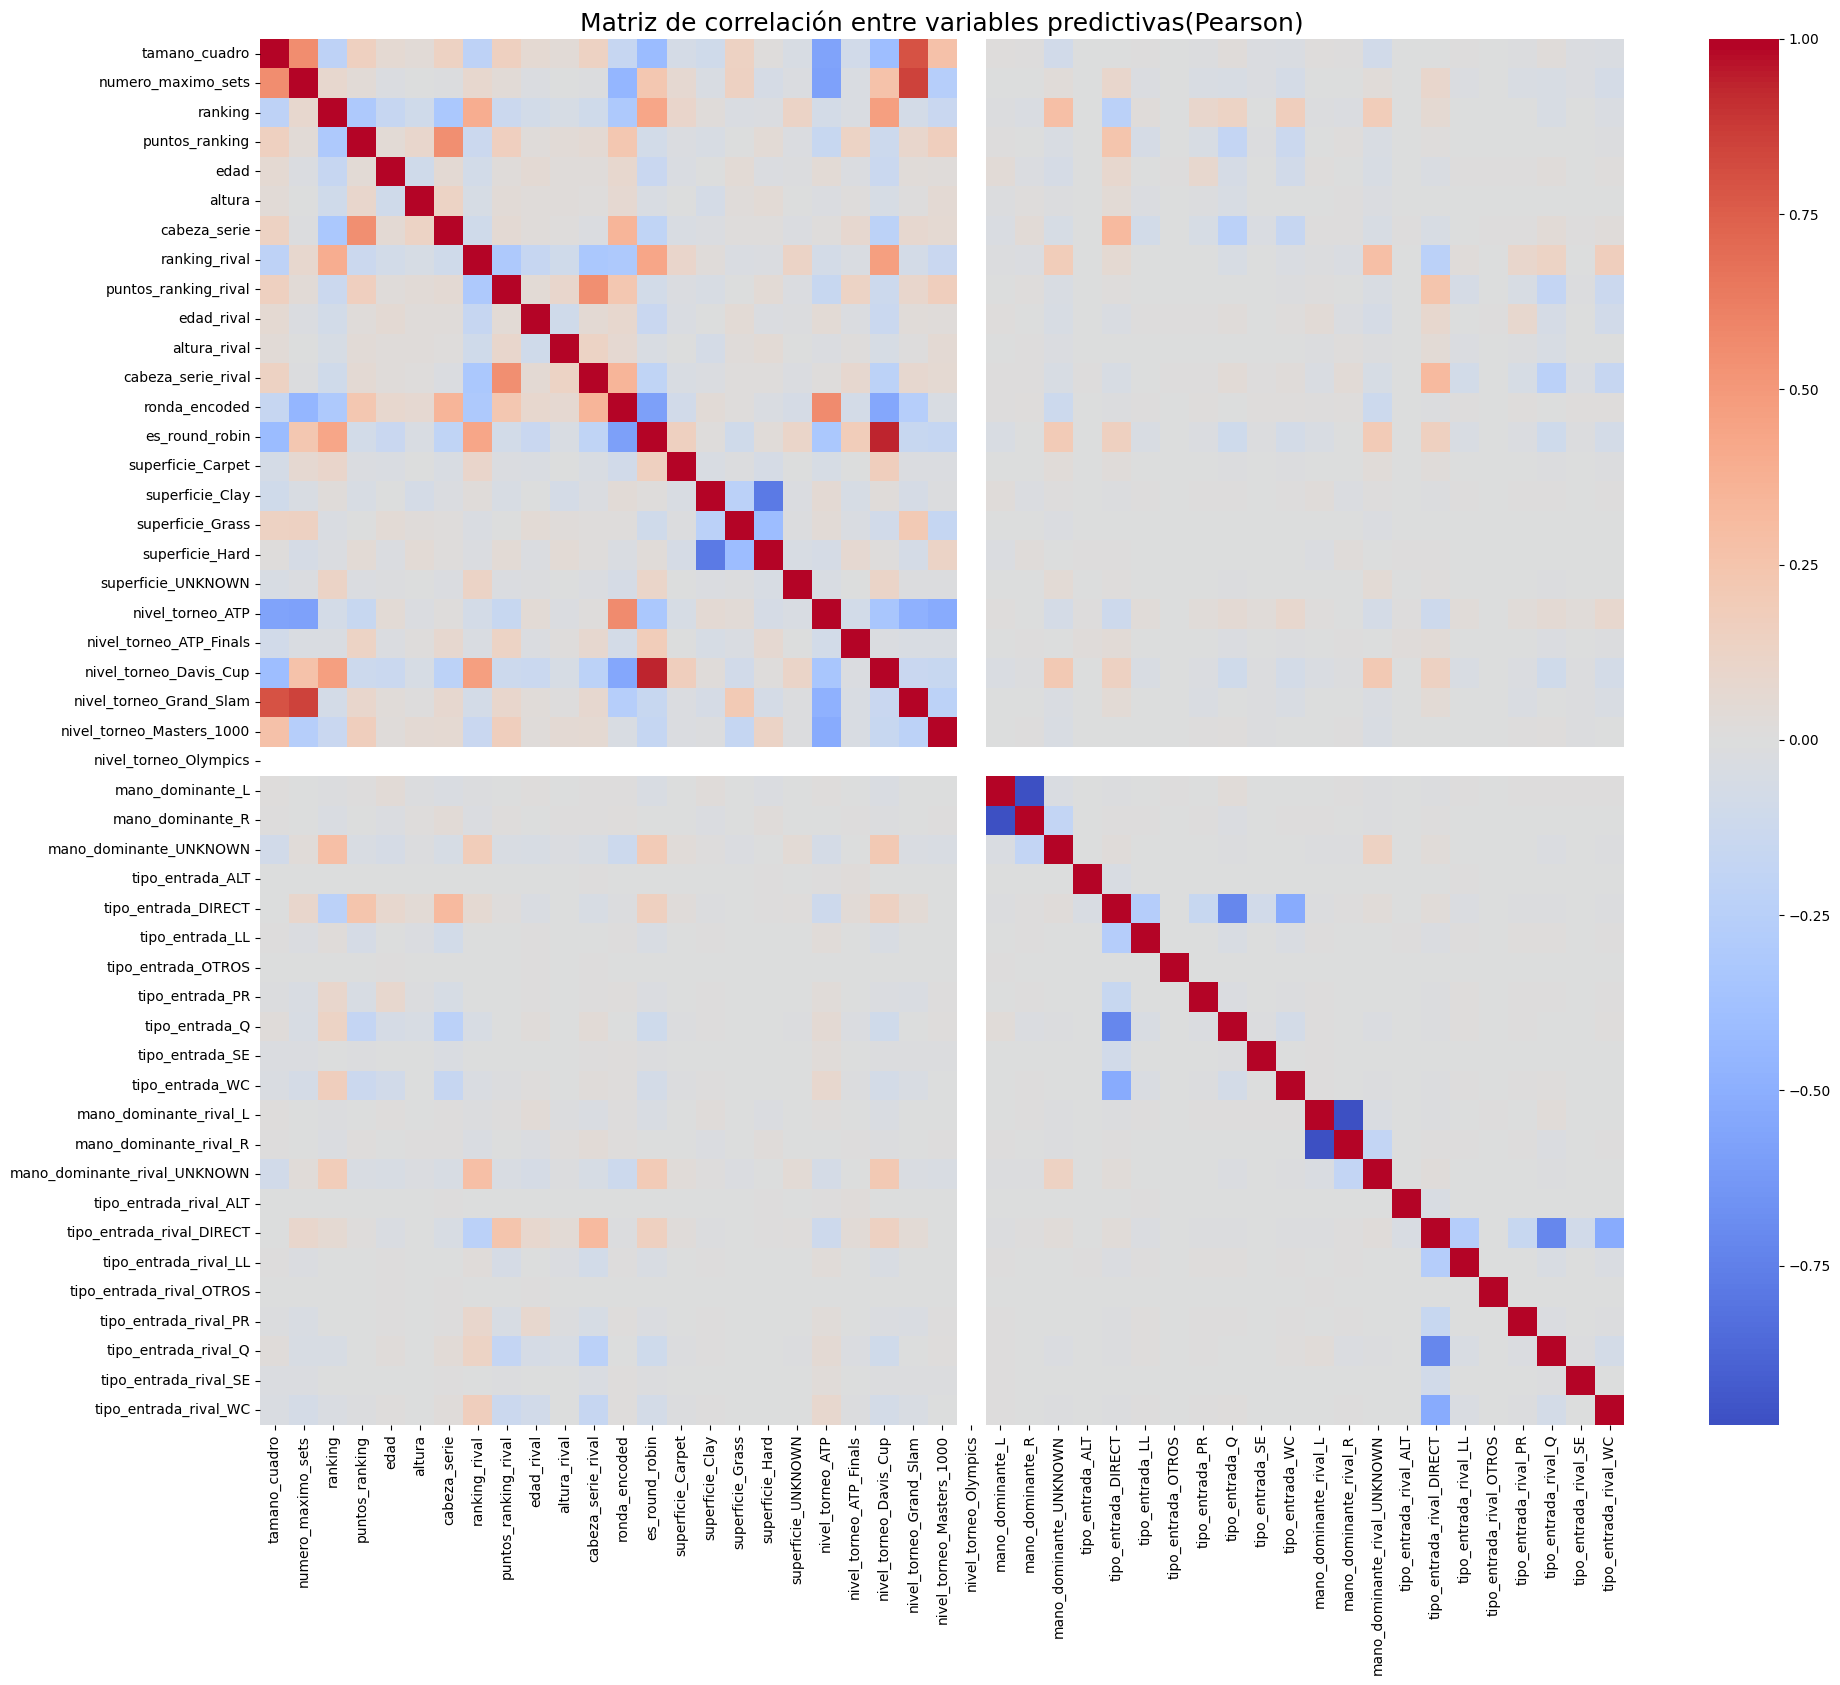

In [32]:
# Paso 20: correlación entre variables predictivas.

# Matriz de correlación de Pearson.
matriz_corr_predictivas = (
    df_jugador[variables_predictivas]
    .corr(method="pearson")
)

# Visualización.
plt.figure(figsize=(22, 18))

sns.heatmap(
    matriz_corr_predictivas,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Matriz de correlación entre variables predictivas(Pearson)",
    fontsize=18
)

plt.show()

In [33]:
# Paso 21: extracción de pares altamente correlacionados.

# Nos quedamos con la parte superior de la matriz.
matriz_superior = matriz_corr_predictivas.where(
    np.triu(
        np.ones(matriz_corr_predictivas.shape),
        k=1
    ).astype(bool)
)

# Convertimos a formato tabla.
pares_correlacion = (
    matriz_superior
    .stack()
    .reset_index()
)

pares_correlacion.columns = [
    "variable_1",
    "variable_2",
    "correlacion(Pearson)"
]

# Valor absoluto para ordenar.
pares_correlacion["abs_corr"] = (
    pares_correlacion["correlacion(Pearson)"].abs()
)

# Filtramos correlaciones altas.
pares_altos = (
    pares_correlacion[
        pares_correlacion["abs_corr"] > 0.3
    ]
    .sort_values(
        "abs_corr",
        ascending=False
    )
)

# Mostramos resultados.
display(
    pares_altos[
        ["variable_1", "variable_2", "correlacion(Pearson)"]
    ].round(4)
)

,variable_1,variable_2,correlacion(Pearson)
804,mano_dominante_L,mano_dominante_R,-0.9768
980,mano_dominante_rival_L,mano_dominante_rival_R,-0.9768
514,es_round_robin,nivel_torneo_Davis_Cup,0.9374
65,numero_maximo_sets,nivel_torneo_Grand_Slam,0.8457
21,tamano_cuadro,nivel_torneo_Grand_Slam,0.7950
571,superficie_Clay,superficie_Hard,-0.7827
885,tipo_entrada_DIRECT,tipo_entrada_Q,-0.7153
1017,tipo_entrada_rival_DIRECT,tipo_entrada_rival_Q,-0.7153
474,ronda_encoded,es_round_robin,-0.5885
62,numero_maximo_sets,nivel_torneo_ATP,-0.5772


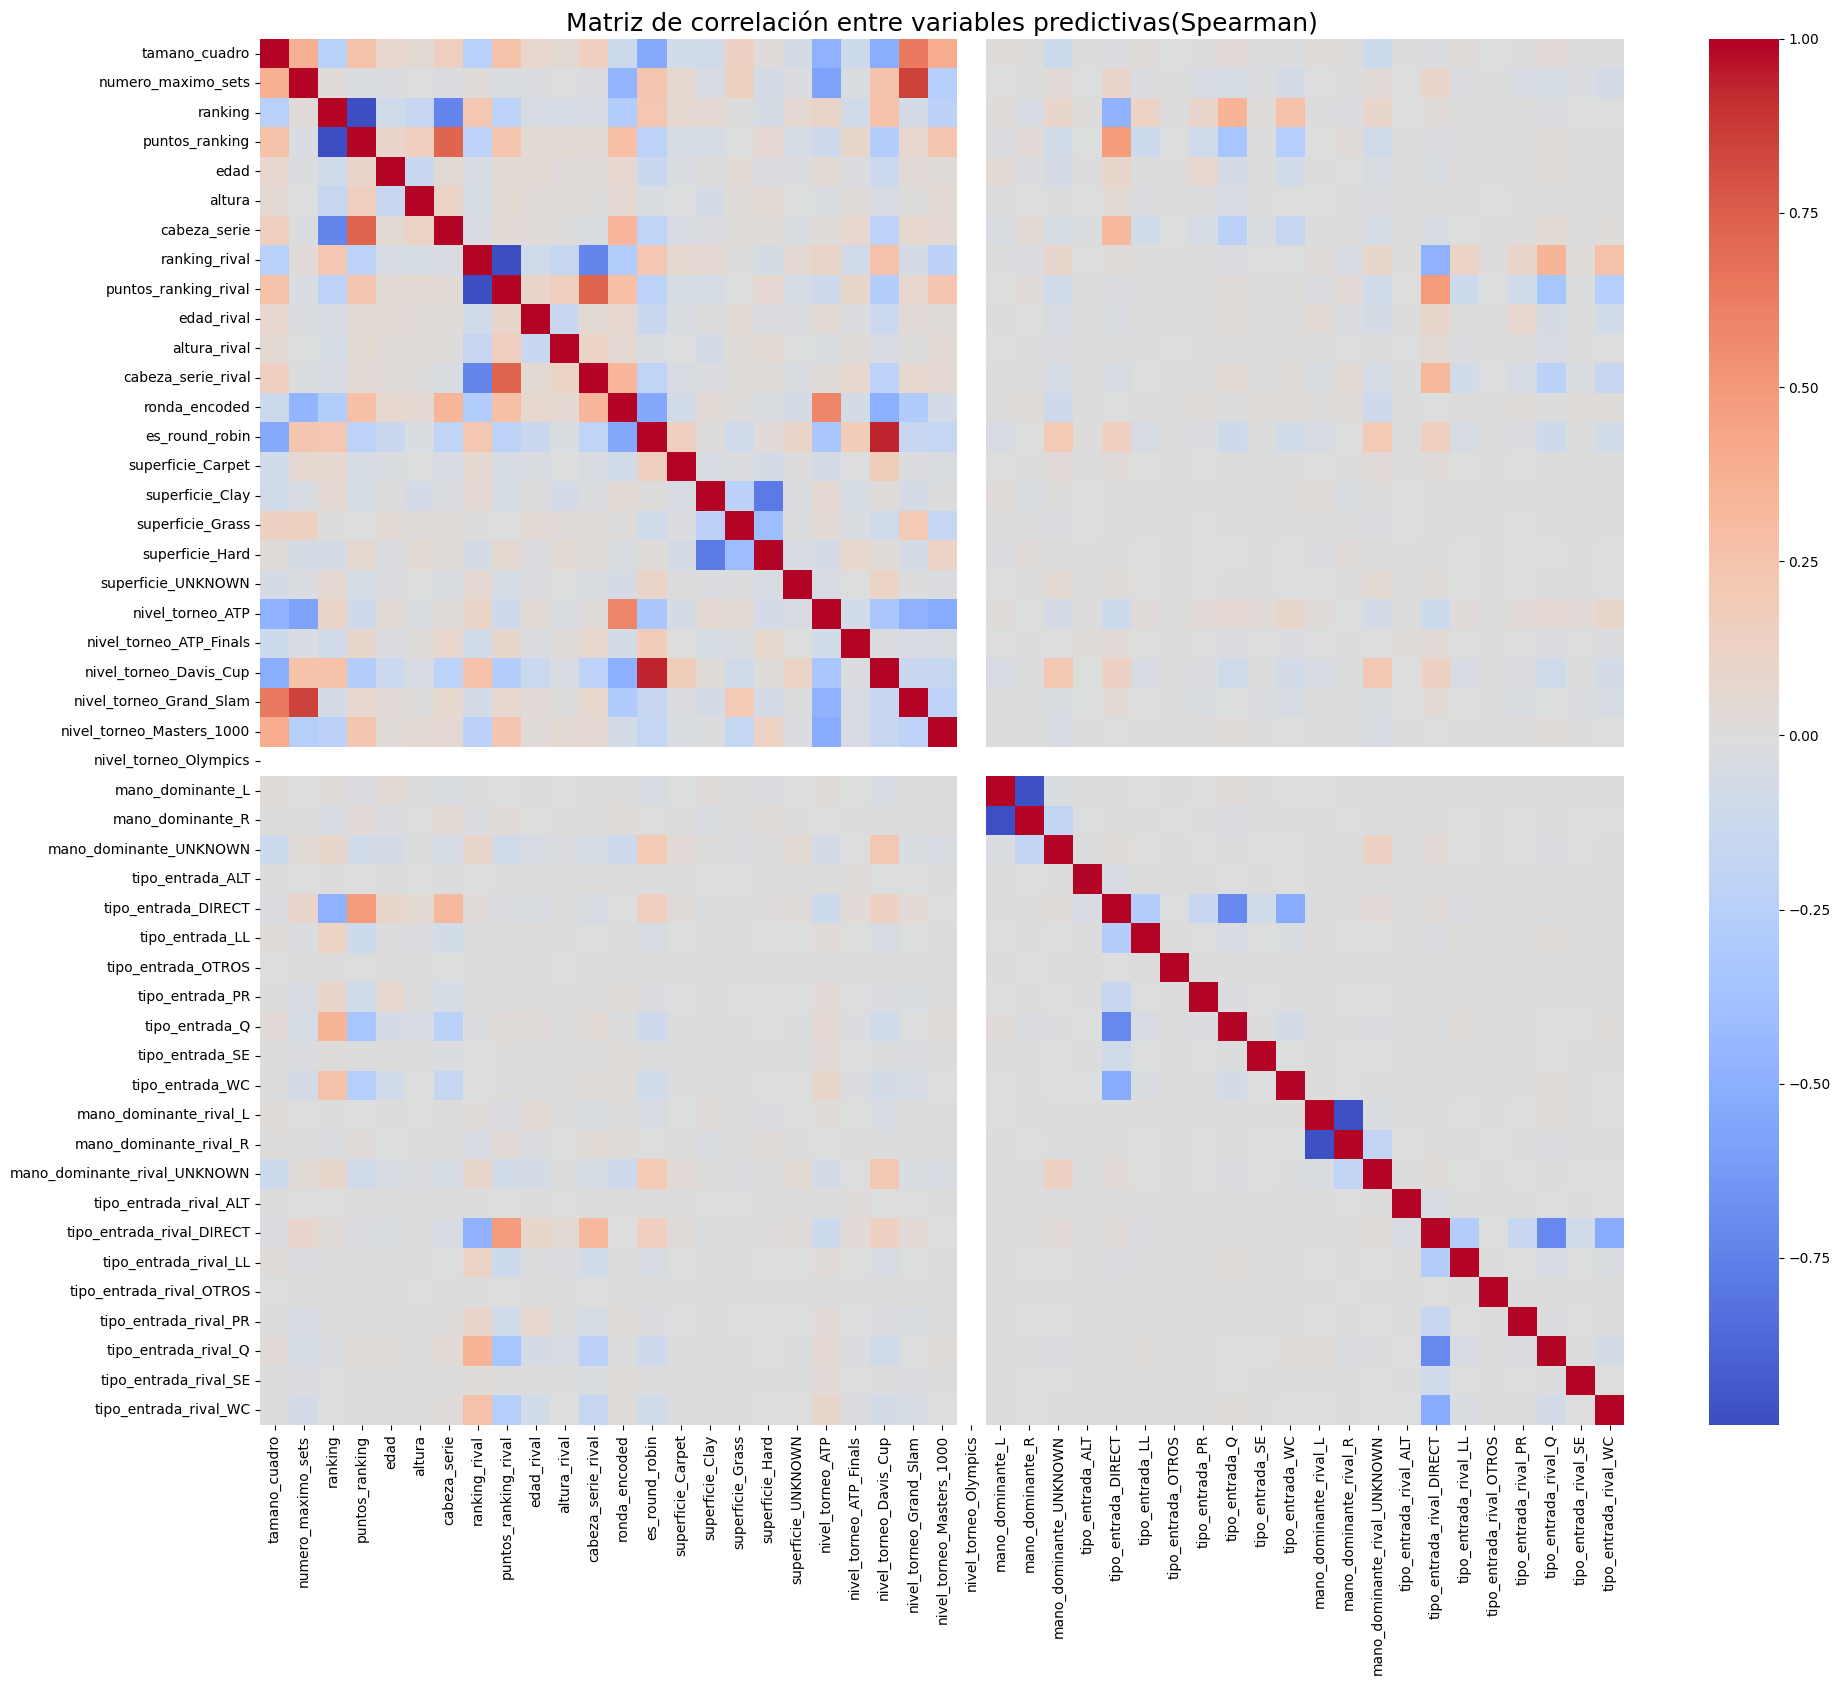

In [34]:
# Paso 20: correlación entre variables predictivas.

# Matriz de correlación de Spearnman.
matriz_corr_predictivas = (
    df_jugador[variables_predictivas]
    .corr(method="spearman")
)

# Visualización.
plt.figure(figsize=(22, 18))

sns.heatmap(
    matriz_corr_predictivas,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Matriz de correlación entre variables predictivas(Spearman)",
    fontsize=18
)

plt.show()

In [35]:
# Paso 21B: extracción de pares altamente correlacionados (Spearman).

# Matriz de correlación Spearman.
matriz_corr_spearman = (
    df_jugador[variables_predictivas]
    .corr(method="spearman")
)

# Parte superior de la matriz.
matriz_superior_spearman = matriz_corr_spearman.where(
    np.triu(
        np.ones(matriz_corr_spearman.shape),
        k=1
    ).astype(bool)
)

# Conversión a tabla.
pares_correlacion_spearman = (
    matriz_superior_spearman
    .stack()
    .reset_index()
)

pares_correlacion_spearman.columns = [
    "variable_1",
    "variable_2",
    "correlacion(Spearman)"
]

# Valor absoluto.
pares_correlacion_spearman["abs_corr"] = (
    pares_correlacion_spearman["correlacion(Spearman)"].abs()
)

# Filtrado.
pares_altos_spearman = (
    pares_correlacion_spearman[
        pares_correlacion_spearman["abs_corr"] > 0.3
    ]
    .sort_values(
        "abs_corr",
        ascending=False
    )
)

# Resultados.
display(
    pares_altos_spearman[
        [
            "variable_1",
            "variable_2",
            "correlacion(Spearman)"
        ]
    ].round(4)
)

,variable_1,variable_2,correlacion(Spearman)
89,ranking,puntos_ranking,-0.9895
294,ranking_rival,puntos_ranking_rival,-0.9895
980,mano_dominante_rival_L,mano_dominante_rival_R,-0.9768
804,mano_dominante_L,mano_dominante_R,-0.9768
514,es_round_robin,nivel_torneo_Davis_Cup,0.9374
65,numero_maximo_sets,nivel_torneo_Grand_Slam,0.8457
571,superficie_Clay,superficie_Hard,-0.7827
297,ranking_rival,cabeza_serie_rival,-0.7267
92,ranking,cabeza_serie,-0.7267
134,puntos_ranking,cabeza_serie,0.7209


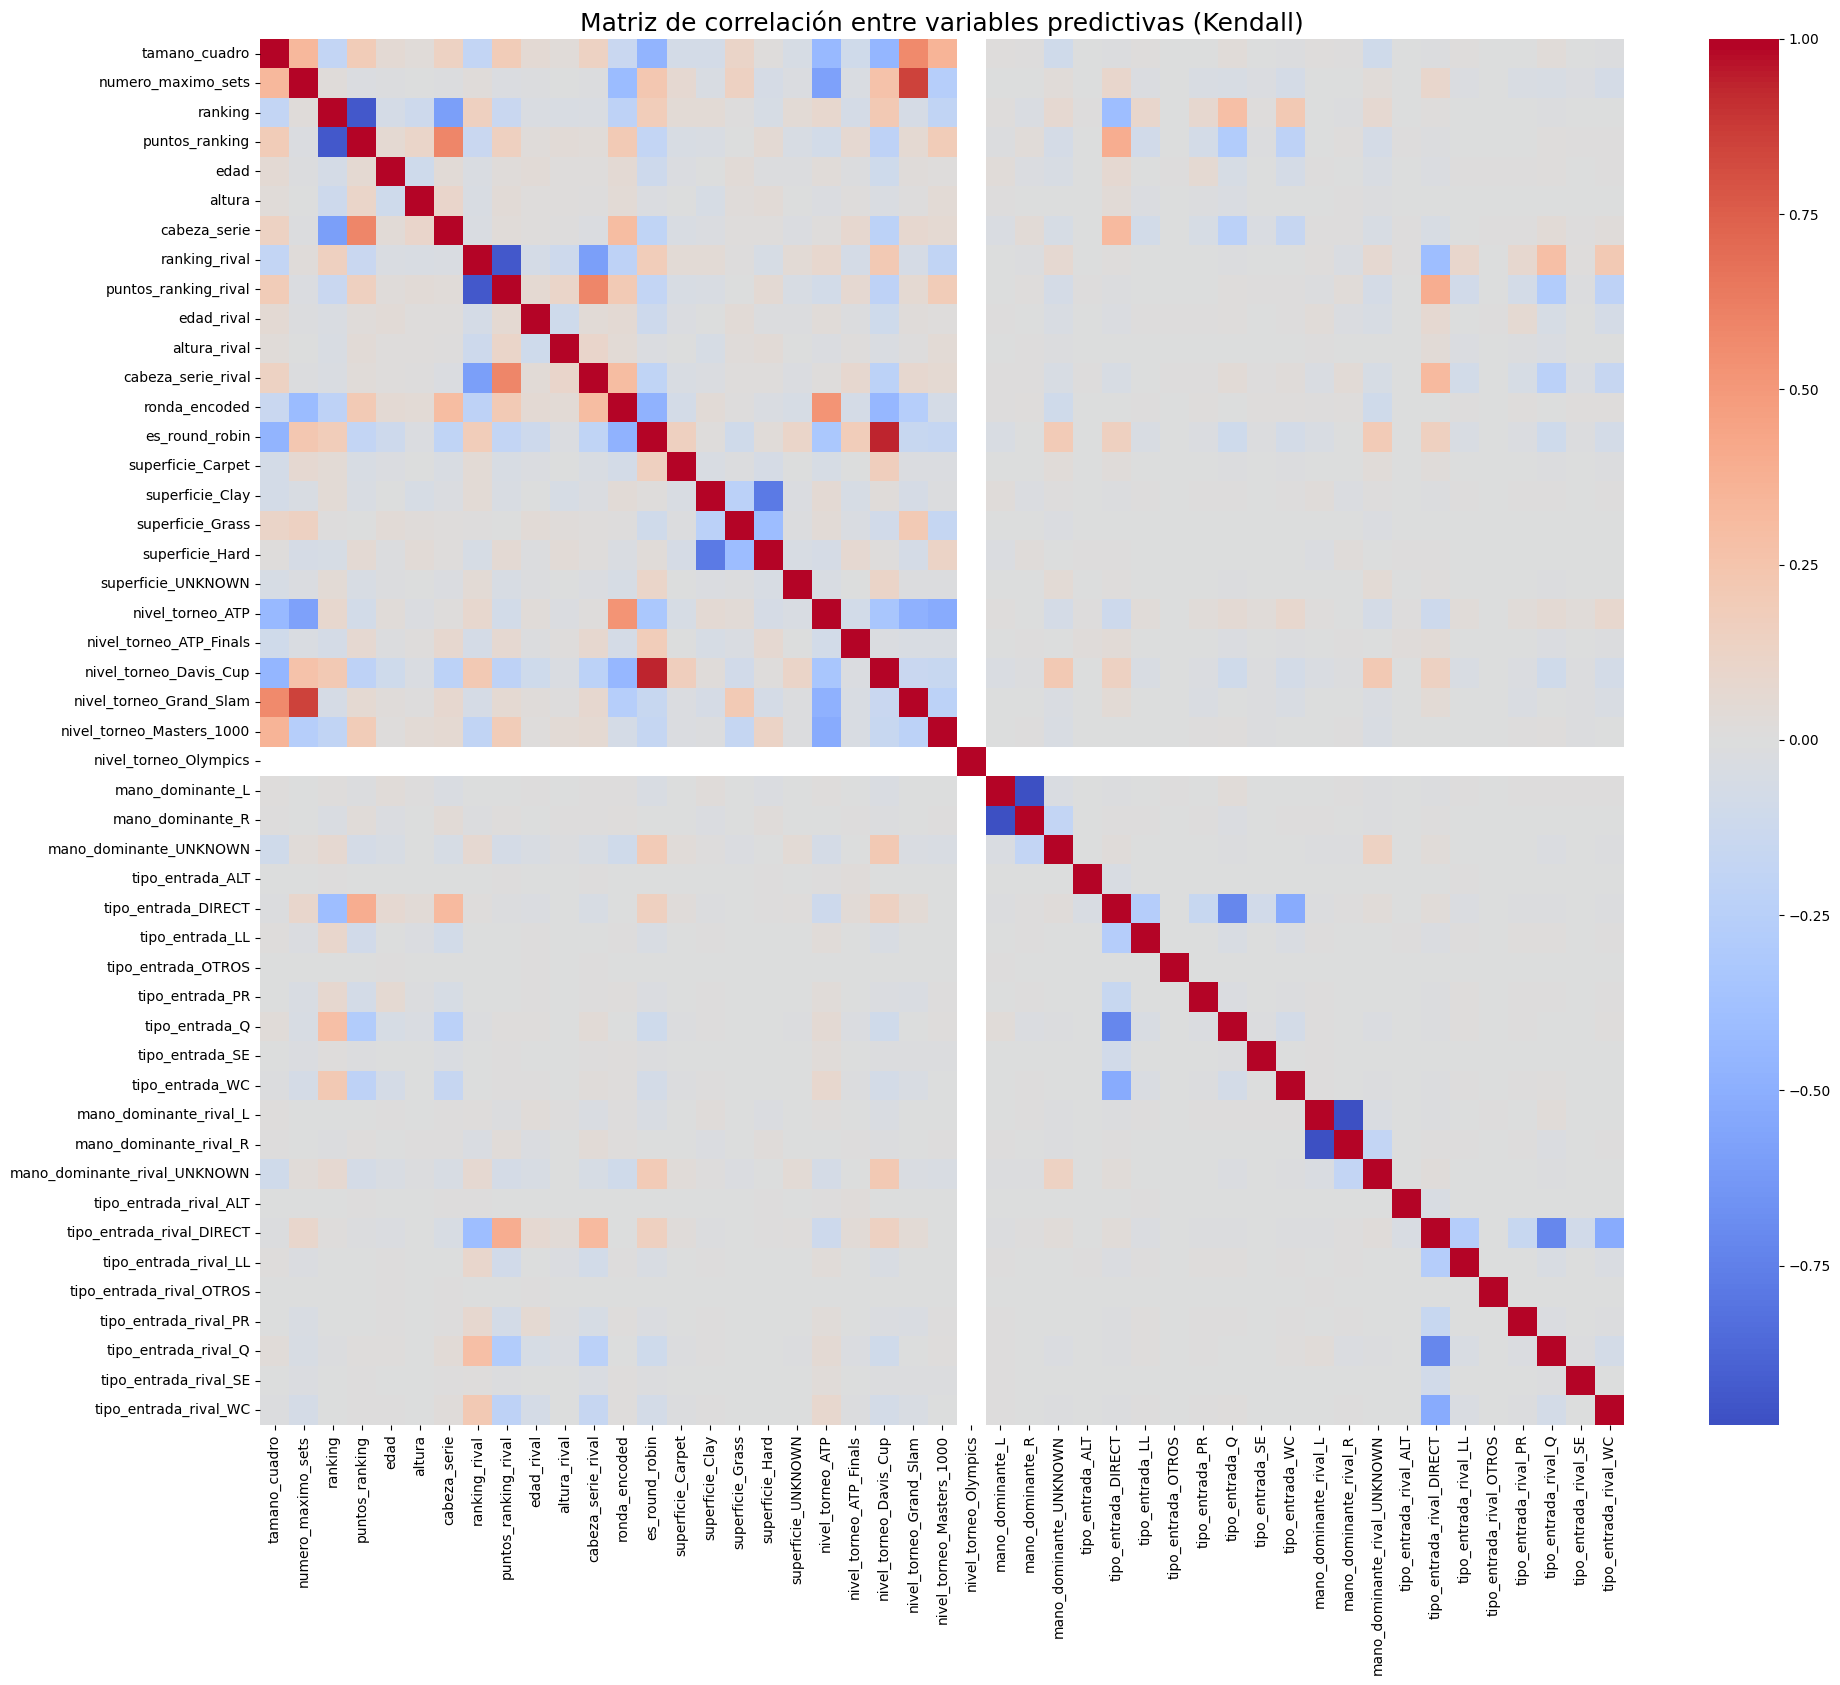

In [36]:
# Paso 20: correlación entre variables predictivas.

# Matriz de correlación de Kendall.
matriz_corr_predictivas = (
    df_jugador[variables_predictivas]
    .corr(method="kendall")
)

# Visualización.
plt.figure(figsize=(22, 18))

sns.heatmap(
    matriz_corr_predictivas,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Matriz de correlación entre variables predictivas (Kendall)",
    fontsize=18
)

plt.show()

In [37]:
# Paso 21C: extracción de pares altamente correlacionados (Kendall).

# Matriz de correlación Kendall.
matriz_corr_kendall = (
    df_jugador[variables_predictivas]
    .corr(method="kendall")
)

# Parte superior de la matriz.
matriz_superior_kendall = matriz_corr_kendall.where(
    np.triu(
        np.ones(matriz_corr_kendall.shape),
        k=1
    ).astype(bool)
)

# Conversión a tabla.
pares_correlacion_kendall = (
    matriz_superior_kendall
    .stack()
    .reset_index()
)

pares_correlacion_kendall.columns = [
    "variable_1",
    "variable_2",
    "correlacion(Kendall)"
]

# Valor absoluto.
pares_correlacion_kendall["abs_corr"] = (
    pares_correlacion_kendall["correlacion(Kendall)"].abs()
)

# Filtrado.
pares_altos_kendall = (
    pares_correlacion_kendall[
        pares_correlacion_kendall["abs_corr"] > 0.3
    ]
    .sort_values(
        "abs_corr",
        ascending=False
    )
)

# Resultados.
display(
    pares_altos_kendall[
        [
            "variable_1",
            "variable_2",
            "correlacion(Kendall)"
        ]
    ].round(4)
)

,variable_1,variable_2,correlacion(Kendall)
804,mano_dominante_L,mano_dominante_R,-0.9768
980,mano_dominante_rival_L,mano_dominante_rival_R,-0.9768
514,es_round_robin,nivel_torneo_Davis_Cup,0.9374
89,ranking,puntos_ranking,-0.9317
294,ranking_rival,puntos_ranking_rival,-0.9317
65,numero_maximo_sets,nivel_torneo_Grand_Slam,0.8457
571,superficie_Clay,superficie_Hard,-0.7827
1017,tipo_entrada_rival_DIRECT,tipo_entrada_rival_Q,-0.7153
885,tipo_entrada_DIRECT,tipo_entrada_Q,-0.7153
297,ranking_rival,cabeza_serie_rival,-0.5953


## Análisis de información mutua

Las correlaciones anteriores permiten estudiar principalmente asociaciones lineales o monótonas. Para complementar este análisis se utiliza la información mutua, que permite detectar dependencias más generales entre cada predictor y `porcentaje_juegos_ganados`.

La información mutua es una medida no negativa y no proporciona información sobre la dirección de la relación. Por este motivo, se interpreta de forma comparativa y como evidencia exploratoria complementaria, no como un criterio aislado de relevancia o selección de variables.

El análisis se realiza mediante `mutual_info_regression` sobre las observaciones que disponen de información completa en los 47 predictores candidatos.

In [38]:
# Paso 22: preparación del dataset para Información Mutua.

from sklearn.feature_selection import (
    mutual_info_regression
)

# =====================================================
# VARIABLES EXCLUIDAS DE INFORMACIÓN MUTUA
# =====================================================

# Se excluyen únicamente de este análisis
# por tener demasiados valores nulos.
variables_excluir_mi = []

# Variables que sí se utilizarán.
variables_predictivas_mi = [
    variable
    for variable in variables_predictivas
    if variable not in variables_excluir_mi
]

# =====================================================
# DATASET TEMPORAL PARA INFORMACIÓN MUTUA
# =====================================================

df_mi = (
    df_jugador[
        variables_predictivas_mi
        + [
            "porcentaje_juegos_ganados"
        ]
    ]
    .dropna()
    .copy()
)

X_mi = df_mi[variables_predictivas_mi]
# =====================================================
# IDENTIFICACIÓN DE VARIABLES DISCRETAS
# =====================================================

variables_discretas_mi = [
    variable
    for variable in variables_predictivas_mi
    if (
        variable in [
            "tamano_cuadro",
            "numero_maximo_sets",
            "ronda_encoded",
            "es_round_robin",
            "cabeza_serie",
            "cabeza_serie_rival",
        ]
        or variable.startswith("superficie_")
        or variable.startswith("nivel_torneo_")
        or variable.startswith("mano_dominante_")
        or variable.startswith("tipo_entrada_")
    )
]

# Para cada variable indicamos True si es discreta
# y False si es continua.
mascara_discretas_mi = [
    variable in variables_discretas_mi
    for variable in variables_predictivas_mi
]

# =====================================================
# COMPROBACIONES
# =====================================================

print("Dimensión dataset de desarrollo:", df_jugador.shape)
print("Dimensión dataset para MI:", df_mi.shape)

print(
    "Variables predictivas usadas en MI:",
    len(variables_predictivas_mi)
)

print(
    "Variables discretas:",
    len(variables_discretas_mi)
)

print(
    "Variables continuas:",
    len(variables_predictivas_mi)
    - len(variables_discretas_mi)
)

print("\nVariables consideradas discretas:")
for variable in variables_discretas_mi:
    print(variable)

print("\nDistribución de es_round_robin en df_mi:")
display(
    df_mi["es_round_robin"].value_counts(
        dropna=False
    )
)

# La máscara debe tener un valor por cada predictor.
assert len(mascara_discretas_mi) == len(
    variables_predictivas_mi
)

# Deben permanecer partidos Round Robin.
assert df_mi["es_round_robin"].sum() > 0

print("\nPreparación para información mutua correcta.")

Dimensión dataset de desarrollo: (76294, 96)
Dimensión dataset para MI: (73242, 48)
Variables predictivas usadas en MI: 47
Variables discretas: 39
Variables continuas: 8

Variables consideradas discretas:
tamano_cuadro
numero_maximo_sets
cabeza_serie
cabeza_serie_rival
ronda_encoded
es_round_robin
superficie_Carpet
superficie_Clay
superficie_Grass
superficie_Hard
superficie_UNKNOWN
nivel_torneo_ATP
nivel_torneo_ATP_Finals
nivel_torneo_Davis_Cup
nivel_torneo_Grand_Slam
nivel_torneo_Masters_1000
nivel_torneo_Olympics
mano_dominante_L
mano_dominante_R
mano_dominante_UNKNOWN
tipo_entrada_ALT
tipo_entrada_DIRECT
tipo_entrada_LL
tipo_entrada_OTROS
tipo_entrada_PR
tipo_entrada_Q
tipo_entrada_SE
tipo_entrada_WC
mano_dominante_rival_L
mano_dominante_rival_R
mano_dominante_rival_UNKNOWN
tipo_entrada_rival_ALT
tipo_entrada_rival_DIRECT
tipo_entrada_rival_LL
tipo_entrada_rival_OTROS
tipo_entrada_rival_PR
tipo_entrada_rival_Q
tipo_entrada_rival_SE
tipo_entrada_rival_WC

Distribución de es_round_rob

es_round_robin
0    67948
1     5294
Name: count, dtype: int64


Preparación para información mutua correcta.


In [39]:
# Paso 23: Información Mutua respecto
# a la proporción de juegos ganados.

y_porcentaje = df_mi["porcentaje_juegos_ganados"]

mi_porcentaje = mutual_info_regression(
    X=X_mi,
    y=y_porcentaje,
    discrete_features=mascara_discretas_mi,
    random_state=42
)

mi_porcentaje_df = (
    pd.DataFrame({
        "variable": variables_predictivas_mi,
        "informacion_mutua_porcentaje_juegos": mi_porcentaje
    })
    .sort_values(
        "informacion_mutua_porcentaje_juegos",
        ascending=False
    )
    .reset_index(drop=True)
)

display(mi_porcentaje_df.round(4))

,variable,informacion_mutua_porcentaje_juegos
0,numero_maximo_sets,0.3023
1,tamano_cuadro,0.2334
2,nivel_torneo_Grand_Slam,0.2204
3,nivel_torneo_ATP,0.1306
4,ronda_encoded,0.0978
5,puntos_ranking,0.0504
6,puntos_ranking_rival,0.0494
7,ranking_rival,0.0441
8,ranking,0.0420
9,nivel_torneo_Masters_1000,0.0310


### Representación conjunta de la asociación y la información aportada por los predictores tradicionales

La asociación marginal de los predictores tradicionales con el porcentaje de juegos ganados se complementó mediante información mutua, ya que ambas medidas describen aspectos diferentes de la relación con el rendimiento.

La correlación de Spearman permite identificar asociaciones monótonas y conservar su dirección, mientras que la información mutua permite detectar dependencias más generales sin imponer una relación lineal o monótona. Por este motivo, ambas medidas se representan en paneles independientes y no se comparan directamente sus magnitudes.

La figura muestra únicamente los predictores con los valores más elevados en cada análisis, con el objetivo de resumir visualmente los principales patrones sin representar de forma innecesaria los 47 predictores candidatos.

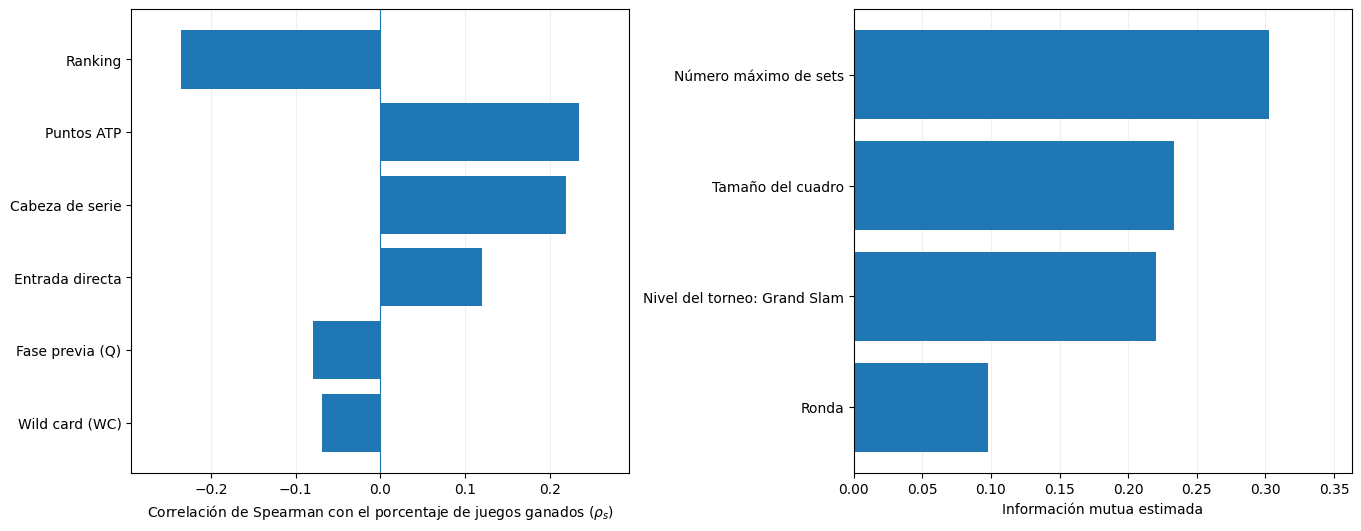

In [40]:
# ============================================================
# FIGURA PARA LA MEMORIA — PREDICTORES TRADICIONALES
# ASOCIACIÓN CON EL RENDIMIENTO E INFORMACIÓN MUTUA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


objetivo_figura = "porcentaje_juegos_ganados"


# ------------------------------------------------------------
# 1. Muestra de desarrollo utilizada en el análisis
# ------------------------------------------------------------

df_figura_base = (
    df_jugador_con_buffers.loc[
        df_jugador_con_buffers[
            "es_desarrollo_modelo"
        ].eq(1)
    ]
    .copy()
)


# Reproducimos la transformación binaria utilizada
# originalmente para la condición de cabeza de serie.

df_figura_base["cabeza_serie"] = (
    df_figura_base["cabeza_serie"]
    .notna()
    .astype(int)
)

df_figura_base["cabeza_serie_rival"] = (
    df_figura_base["cabeza_serie_rival"]
    .notna()
    .astype(int)
)


assert (
    df_figura_base["es_desarrollo_modelo"]
    .eq(1)
    .all()
)

assert not (
    df_figura_base["match_year"]
    .isin([2008, 2021, 2024])
    .any()
)


# ------------------------------------------------------------
# 2. Spearman respecto al porcentaje de juegos ganados
# ------------------------------------------------------------

spearman_figura = (
    df_figura_base[
        variables_predictivas_mi
        + [objetivo_figura]
    ]
    .corr(method="spearman")[
        objetivo_figura
    ]
    .loc[
        variables_predictivas_mi
    ]
)


# Un único representante de cada concepto.
# Las correspondientes variables del rival presentan
# la misma magnitud y signo contrario por la estructura
# recíproca jugador-partido.

variables_spearman_figura = [
    "ranking",
    "puntos_ranking",
    "cabeza_serie",
    "tipo_entrada_DIRECT",
    "tipo_entrada_Q",
    "tipo_entrada_WC"
]


tabla_spearman_figura = pd.DataFrame({
    "variable": variables_spearman_figura,
    "spearman": [
        spearman_figura.loc[variable]
        for variable in variables_spearman_figura
    ]
})


tabla_spearman_figura["abs_spearman"] = (
    tabla_spearman_figura["spearman"].abs()
)


tabla_spearman_figura = (
    tabla_spearman_figura
    .sort_values(
        "abs_spearman",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Información mutua
# ------------------------------------------------------------

# Se seleccionan conceptos distintos y con una contribución
# suficientemente destacada.
#
# Para nivel_torneo se representa únicamente Grand Slam,
# que es su categoría individual con mayor información mutua,
# evitando mostrar varias dummies del mismo predictor.

variables_mi_figura = [
    "numero_maximo_sets",
    "tamano_cuadro",
    "nivel_torneo_Grand_Slam",
    "ronda_encoded"
]


tabla_mi_figura = (
    mi_porcentaje_df
    .set_index("variable")
    .loc[variables_mi_figura]
    .reset_index()
)


tabla_mi_figura = (
    tabla_mi_figura
    .sort_values(
        "informacion_mutua_porcentaje_juegos",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Etiquetas interpretables
# ------------------------------------------------------------

etiquetas_spearman = {
    "ranking":
        "Ranking",

    "puntos_ranking":
        "Puntos ATP",

    "cabeza_serie":
        "Cabeza de serie",

    "tipo_entrada_DIRECT":
        "Entrada directa",

    "tipo_entrada_Q":
        "Fase previa (Q)",

    "tipo_entrada_WC":
        "Wild card (WC)"
}


etiquetas_mi = {
    "numero_maximo_sets":
        "Número máximo de sets",

    "tamano_cuadro":
        "Tamaño del cuadro",

    "nivel_torneo_Grand_Slam":
        "Nivel del torneo: Grand Slam",

    "ronda_encoded":
        "Ronda"
}


tabla_spearman_figura["etiqueta"] = (
    tabla_spearman_figura["variable"]
    .map(etiquetas_spearman)
)


tabla_mi_figura["etiqueta"] = (
    tabla_mi_figura["variable"]
    .map(etiquetas_mi)
)


# ------------------------------------------------------------
# 5. Figura
# ------------------------------------------------------------

figura, (eje_1, eje_2) = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.2),
    constrained_layout=True
)


# ============================================================
# PANEL A — ASOCIACIÓN MONÓTONA
# ============================================================

eje_1.barh(
    tabla_spearman_figura["etiqueta"],
    tabla_spearman_figura["spearman"]
)

eje_1.axvline(
    0,
    linewidth=0.8
)

limite_spearman = (
    tabla_spearman_figura[
        "abs_spearman"
    ].max()
    * 1.25
)

eje_1.set_xlim(
    -limite_spearman,
    limite_spearman
)

eje_1.set_xlabel(
    r"Correlación de Spearman con el porcentaje "
    r"de juegos ganados ($\rho_s$)"
)

eje_1.set_ylabel("")

eje_1.grid(
    axis="x",
    alpha=0.2
)

eje_1.set_axisbelow(True)


# ============================================================
# PANEL B — DEPENDENCIA GENERAL
# ============================================================

eje_2.barh(
    tabla_mi_figura["etiqueta"],
    tabla_mi_figura[
        "informacion_mutua_porcentaje_juegos"
    ]
)

limite_mi = (
    tabla_mi_figura[
        "informacion_mutua_porcentaje_juegos"
    ].max()
    * 1.20
)

eje_2.set_xlim(
    0,
    limite_mi
)

eje_2.set_xlabel(
    "Información mutua estimada"
)

eje_2.set_ylabel("")

eje_2.grid(
    axis="x",
    alpha=0.2
)

eje_2.set_axisbelow(True)


plt.show()

## Selección de los predictores tradicionales

La selección final no se basa en un único umbral estadístico. Se consideran conjuntamente la asociación con el rendimiento, la información mutua, la redundancia entre predictores, la frecuencia de las categorías, la disponibilidad de la información y su interpretación dentro del contexto competitivo.

Las categorías con una representación muy reducida se revisaron individualmente, sin aplicar un umbral automático de eliminación.

La decisión de conservar o retirar cada indicador tuvo en cuenta su frecuencia, su aportación estadística, la redundancia con otras variables y su interpretación dentro del contexto competitivo. De este modo, se eliminaron aquellas categorías minoritarias cuya conservación no aportaba información suficiente para justificar su inclusión en el conjunto final de predictores.

In [41]:
# =========================================================
# Paso 24: eliminación de variables redundantes y raras.
# =========================================================

# ---------------------------------------------------------
# VARIABLES A ELIMINAR
# ---------------------------------------------------------

variables_eliminar = [

    # Redundancia fuerte con ranking.
    "puntos_ranking",
    "puntos_ranking_rival",

    # Superficie extremadamente rara.
    "superficie_Carpet",

    # Categorías muy raras de tipo_entrada.
    "tipo_entrada_ALT",
    "tipo_entrada_rival_ALT",

    "tipo_entrada_SE",
    "tipo_entrada_rival_SE",

    "tipo_entrada_OTROS",
    "tipo_entrada_rival_OTROS",
    "superficie_UNKNOWN",

"nivel_torneo_Olympics",

"mano_dominante_UNKNOWN",
"mano_dominante_rival_UNKNOWN",

"tipo_entrada_PR",
"tipo_entrada_rival_PR"
]

print("Frecuencia de variables eliminadas en muestra de desarrollo:")

variables_eliminar_presentes = [
    var for var in variables_eliminar
    if var in df_jugador.columns
]

resumen_eliminadas = pd.DataFrame({
    "variable": variables_eliminar_presentes,
    "frecuencia": [
        df_jugador[var].sum()
        if df_jugador[var].dropna().isin([0, 1]).all()
        else np.nan
        for var in variables_eliminar_presentes
    ],
    "porcentaje": [
        (
            df_jugador[var].sum() / len(df_jugador) * 100
            if df_jugador[var].dropna().isin([0, 1]).all()
            else np.nan
        )
        for var in variables_eliminar_presentes
    ]
})

display(resumen_eliminadas)

# ---------------------------------------------------------
# Eliminamos variables del dataset.
# ---------------------------------------------------------

df_jugador = df_jugador.drop(
    columns=variables_eliminar,
    errors="ignore"
)

# ---------------------------------------------------------
# Actualizamos lista de variables predictivas.
# ---------------------------------------------------------

variables_predictivas = [
    var for var in variables_predictivas
    if var not in variables_eliminar
]

# =========================================================
# RESUMEN FINAL
# =========================================================

print("="*70)
print("VARIABLES ELIMINADAS")
print("="*70)

for var in variables_eliminar:
    print(var)

print("\n" + "="*70)
print("NÚMERO FINAL DE VARIABLES PREDICTIVAS")
print("="*70)

print(len(variables_predictivas))

print("\n" + "="*70)
print("VARIABLES PREDICTIVAS FINALES")
print("="*70)

for var in variables_predictivas:
    print(var)

Frecuencia de variables eliminadas en muestra de desarrollo:


,variable,frecuencia,porcentaje
0,puntos_ranking,NaN,NaN
1,puntos_ranking_rival,NaN,NaN
2,superficie_Carpet,220.0,0.288358
3,tipo_entrada_ALT,19.0,0.024904
4,tipo_entrada_rival_ALT,19.0,0.024904
5,tipo_entrada_SE,126.0,0.165151
6,tipo_entrada_rival_SE,126.0,0.165151
7,tipo_entrada_OTROS,1.0,0.001311
8,tipo_entrada_rival_OTROS,1.0,0.001311
9,superficie_UNKNOWN,106.0,0.138936


VARIABLES ELIMINADAS
puntos_ranking
puntos_ranking_rival
superficie_Carpet
tipo_entrada_ALT
tipo_entrada_rival_ALT
tipo_entrada_SE
tipo_entrada_rival_SE
tipo_entrada_OTROS
tipo_entrada_rival_OTROS
superficie_UNKNOWN
nivel_torneo_Olympics
mano_dominante_UNKNOWN
mano_dominante_rival_UNKNOWN
tipo_entrada_PR
tipo_entrada_rival_PR

NÚMERO FINAL DE VARIABLES PREDICTIVAS
32

VARIABLES PREDICTIVAS FINALES
tamano_cuadro
numero_maximo_sets
ranking
edad
altura
cabeza_serie
ranking_rival
edad_rival
altura_rival
cabeza_serie_rival
ronda_encoded
es_round_robin
superficie_Clay
superficie_Grass
superficie_Hard
nivel_torneo_ATP
nivel_torneo_ATP_Finals
nivel_torneo_Davis_Cup
nivel_torneo_Grand_Slam
nivel_torneo_Masters_1000
mano_dominante_L
mano_dominante_R
tipo_entrada_DIRECT
tipo_entrada_LL
tipo_entrada_Q
tipo_entrada_WC
mano_dominante_rival_L
mano_dominante_rival_R
tipo_entrada_rival_DIRECT
tipo_entrada_rival_LL
tipo_entrada_rival_Q
tipo_entrada_rival_WC


### Construcción de variables diferenciales jugador–rival

Para representar directamente las diferencias entre ambos participantes se sustituyen las variables individuales de ranking, edad y altura por variables diferenciales.

Para edad y altura se utiliza la convención jugador menos rival. En el caso del ranking se define

$$
\texttt{diff\_ranking}
=
\texttt{ranking\_rival}
-
\texttt{ranking\_jugador},
$$

de modo que un valor positivo indica que el jugador observado presenta una mejor posición en el ranking, ya que posiciones numéricamente menores representan un mejor ranking.

In [42]:
# =====================================================
# Paso 25: creación de variables diferenciales jugador-rival
# =====================================================

# Diferencia de ranking:
# Valor positivo = el jugador tiene mejor ranking que el rival.
df_jugador["diff_ranking"] = (
    df_jugador["ranking_rival"] - df_jugador["ranking"]
)

# Diferencia de edad:
# Valor positivo = el jugador es mayor que el rival.
df_jugador["diff_edad"] = (
    df_jugador["edad"] - df_jugador["edad_rival"]
)

# Diferencia de altura:
# Valor positivo = el jugador es más alto que el rival.
df_jugador["diff_altura"] = (
    df_jugador["altura"] - df_jugador["altura_rival"]
)

# =====================================================
# Variables originales que ya quedan representadas
# por las variables diferenciales
# =====================================================

variables_eliminar_diferenciales = [
    "ranking",
    "ranking_rival",
    "edad",
    "edad_rival",
    "altura",
    "altura_rival"
]

# Eliminamos del dataset.
df_jugador = df_jugador.drop(
    columns=variables_eliminar_diferenciales,
    errors="ignore"
)

# Actualizamos variables predictivas.
variables_predictivas = [
    var for var in variables_predictivas
    if var not in variables_eliminar_diferenciales
]

# Añadimos las nuevas variables diferenciales.
variables_predictivas += [
    "diff_ranking",
    "diff_edad",
    "diff_altura"
]

# Eliminamos posibles duplicados.
variables_predictivas = list(dict.fromkeys(variables_predictivas))

# =====================================================
# Comprobación final
# =====================================================

print("Variables eliminadas:")
for var in variables_eliminar_diferenciales:
    print(var)

print("\nNuevas variables diferenciales:")
print("diff_ranking")
print("diff_edad")
print("diff_altura")

print("\nNúmero final de variables predictivas:")
print(len(variables_predictivas))

print("\nVariables predictivas finales:")
display(variables_predictivas)

Variables eliminadas:
ranking
ranking_rival
edad
edad_rival
altura
altura_rival

Nuevas variables diferenciales:
diff_ranking
diff_edad
diff_altura

Número final de variables predictivas:
29

Variables predictivas finales:


['tamano_cuadro',
 'numero_maximo_sets',
 'cabeza_serie',
 'cabeza_serie_rival',
 'ronda_encoded',
 'es_round_robin',
 'superficie_Clay',
 'superficie_Grass',
 'superficie_Hard',
 'nivel_torneo_ATP',
 'nivel_torneo_ATP_Finals',
 'nivel_torneo_Davis_Cup',
 'nivel_torneo_Grand_Slam',
 'nivel_torneo_Masters_1000',
 'mano_dominante_L',
 'mano_dominante_R',
 'tipo_entrada_DIRECT',
 'tipo_entrada_LL',
 'tipo_entrada_Q',
 'tipo_entrada_WC',
 'mano_dominante_rival_L',
 'mano_dominante_rival_R',
 'tipo_entrada_rival_DIRECT',
 'tipo_entrada_rival_LL',
 'tipo_entrada_rival_Q',
 'tipo_entrada_rival_WC',
 'diff_ranking',
 'diff_edad',
 'diff_altura']

In [43]:
# =========================================================
# Paso 26: frecuencia de variables categóricas codificadas.
# =========================================================

# Variables binarias/categóricas finales.

variables_categoricas_encoded = [

    var for var in variables_predictivas

    if (
        var.startswith("superficie_")
        or var.startswith("nivel_torneo_")
        or var.startswith("mano_dominante_")
        or var.startswith("tipo_entrada_")
    )
]

# Añadimos manualmente es_round_robin.
variables_categoricas_encoded += [
    "es_round_robin"
]

# =========================================================
# FRECUENCIA DE CADA VARIABLE
# =========================================================

print("="*70)
print("FRECUENCIA DE VARIABLES CATEGÓRICAS CODIFICADAS")
print("="*70)

for var in variables_categoricas_encoded:

    frecuencia = df_jugador[var].sum()

    porcentaje = (
        frecuencia / len(df_jugador)
    ) * 100

    print(f"\n{var}")
    print(f"Frecuencia: {int(frecuencia)}")
    print(f"Porcentaje: {porcentaje:.3f}%")

FRECUENCIA DE VARIABLES CATEGÓRICAS CODIFICADAS

superficie_Clay
Frecuencia: 23786
Porcentaje: 31.177%

superficie_Grass
Frecuencia: 8322
Porcentaje: 10.908%

superficie_Hard
Frecuencia: 43860
Porcentaje: 57.488%

nivel_torneo_ATP
Frecuencia: 40850
Porcentaje: 53.543%

nivel_torneo_ATP_Finals
Frecuencia: 478
Porcentaje: 0.627%

nivel_torneo_Davis_Cup
Frecuencia: 7056
Porcentaje: 9.248%

nivel_torneo_Grand_Slam
Frecuencia: 13158
Porcentaje: 17.246%

nivel_torneo_Masters_1000
Frecuencia: 14752
Porcentaje: 19.336%

mano_dominante_L
Frecuencia: 10204
Porcentaje: 13.375%

mano_dominante_R
Frecuencia: 65668
Porcentaje: 86.072%

tipo_entrada_DIRECT
Frecuencia: 63323
Porcentaje: 82.999%

tipo_entrada_LL
Frecuencia: 1126
Porcentaje: 1.476%

tipo_entrada_Q
Frecuencia: 7238
Porcentaje: 9.487%

tipo_entrada_WC
Frecuencia: 4075
Porcentaje: 5.341%

mano_dominante_rival_L
Frecuencia: 10204
Porcentaje: 13.375%

mano_dominante_rival_R
Frecuencia: 65668
Porcentaje: 86.072%

tipo_entrada_rival_DIRECT
Fre

## Aplicación de las decisiones al conjunto operativo completo

Una vez finalizada la selección utilizando exclusivamente la muestra de desarrollo, se recupera el conjunto operativo completo, incluidos los años buffer y 2024.

Las decisiones ya establecidas se aplican de forma idéntica a todas las observaciones, sin volver a evaluar ni seleccionar variables utilizando la temporada reservada para la evaluación temporal externa.

In [44]:
# ============================================================
# RESTAURAR DATASET COMPLETO Y APLICAR DECISIONES FINALES
# ============================================================

df_jugador = df_jugador_con_buffers.copy()

# Comprobamos que recuperamos las columnas originales necesarias.
columnas_necesarias_diferenciales = [
    "ranking",
    "ranking_rival",
    "edad",
    "edad_rival",
    "altura",
    "altura_rival"
]

faltan = [
    col for col in columnas_necesarias_diferenciales
    if col not in df_jugador.columns
]

assert len(faltan) == 0, (
    "Faltan columnas para crear diferenciales: "
    f"{faltan}. Ejecuta Kernel > Restart & Run All desde el principio."
)

# Transformación binaria de cabeza de serie.
df_jugador["cabeza_serie"] = (
    df_jugador["cabeza_serie"]
    .notna()
    .astype(int)
)

df_jugador["cabeza_serie_rival"] = (
    df_jugador["cabeza_serie_rival"]
    .notna()
    .astype(int)
)

# Creamos variables diferenciales jugador-rival ANTES de eliminar las originales.
df_jugador["diff_ranking"] = (
    df_jugador["ranking_rival"] - df_jugador["ranking"]
)

df_jugador["diff_edad"] = (
    df_jugador["edad"] - df_jugador["edad_rival"]
)

df_jugador["diff_altura"] = (
    df_jugador["altura"] - df_jugador["altura_rival"]
)

# Variables originales que ya quedan representadas por diferenciales.
variables_eliminar_diferenciales = [
    "ranking",
    "ranking_rival",
    "edad",
    "edad_rival",
    "altura",
    "altura_rival"
]

# Eliminamos variables redundantes, raras y originales sustituidas por diferenciales.
df_jugador = df_jugador.drop(
    columns=variables_eliminar + variables_eliminar_diferenciales,
    errors="ignore"
)

# Actualizamos lista de variables predictivas finales.
variables_predictivas = [
    var for var in variables_predictivas
    if var not in variables_eliminar
    and var not in variables_eliminar_diferenciales
]

for var in [
    "diff_ranking",
    "diff_edad",
    "diff_altura"
]:
    if var not in variables_predictivas:
        variables_predictivas.append(var)

# Comprobaciones.
assert df_jugador["match_year"].isin([2008, 2021]).any()
assert df_jugador["es_buffer_carga"].eq(1).any()

assert (
    df_jugador["es_muestra_estudio"]
    + df_jugador["es_buffer_carga"]
).eq(1).all()

assert set(variables_predictivas).issubset(df_jugador.columns)

print("Dataset completo con buffers y variables finales:")
print(df_jugador.shape)

assert df_jugador["es_validacion_temporal"].eq(1).any()
assert df_jugador["es_desarrollo_modelo"].eq(1).any()

assert (
    df_jugador["es_desarrollo_modelo"]
    + df_jugador["es_validacion_temporal"]
).eq(df_jugador["es_muestra_estudio"]).all()

assert (
    df_jugador["es_buffer_carga"]
    + df_jugador["es_desarrollo_modelo"]
    + df_jugador["es_validacion_temporal"]
).eq(1).all()

display(
    df_jugador.groupby(
        [
            "match_year",
            "es_buffer_carga",
            "es_desarrollo_modelo",
            "es_validacion_temporal",
            "es_muestra_estudio"
        ]
    )
    .size()
    .rename("observaciones")
    .to_frame()
)

Dataset completo con buffers y variables finales:
(94032, 78)


,,,,,observaciones
match_year,es_buffer_carga,es_desarrollo_modelo,es_validacion_temporal,es_muestra_estudio,
2008,1,0,0,0,6204
2009,0,1,0,1,6138
2010,0,1,0,1,6026
2011,0,1,0,1,6000
2012,0,1,0,1,5980
2013,0,1,0,1,5846
2014,0,1,0,1,5748
2015,0,1,0,1,5866
2016,0,1,0,1,5840


In [45]:
# Comprobación final antes de guardar.

columnas_obligatorias = [
    "match_year",
    "es_muestra_estudio",
    "es_buffer_carga",
    "fecha_torneo",
    "juegos_ganados",
    "juegos_perdidos",
    "sets_ganados",
    "sets_perdidos",
    "total_juegos",
    "total_sets",
    "porcentaje_juegos_ganados"
]

assert set(columnas_obligatorias).issubset(df_jugador.columns)

assert 2020 not in df_jugador["match_year"].unique()

assert (
    df_jugador["es_muestra_estudio"]
    + df_jugador["es_buffer_carga"]
).eq(1).all()

assert df_jugador["total_juegos"].ge(0).all()
assert df_jugador["total_sets"].ge(0).all()

display(
    df_jugador.groupby(
        [
            "match_year",
            "es_muestra_estudio",
            "es_buffer_carga"
        ]
    )
    .size()
    .rename("observaciones")
    .to_frame()
)

,,,observaciones
match_year,es_muestra_estudio,es_buffer_carga,
2008,0,1,6204
2009,1,0,6138
2010,1,0,6026
2011,1,0,6000
2012,1,0,5980
2013,1,0,5846
2014,1,0,5748
2015,1,0,5866
2016,1,0,5840


In [46]:
ANIOS_ESTUDIO = (
    list(range(2009, 2020))
    + [2022, 2023, 2024]
)

ANIOS_BUFFER_CARGA = [
    2008,
    2021
]

assert df_jugador.loc[
    df_jugador["es_muestra_estudio"].eq(1),
    "match_year"
].isin(ANIOS_ESTUDIO).all()

assert df_jugador.loc[
    df_jugador["es_buffer_carga"].eq(1),
    "match_year"
].isin(ANIOS_BUFFER_CARGA).all()

assert df_jugador.loc[
    df_jugador["match_year"].isin(ANIOS_BUFFER_CARGA),
    "es_muestra_estudio"
].eq(0).all()

assert df_jugador.loc[
    df_jugador["match_year"].isin(ANIOS_BUFFER_CARGA),
    "es_buffer_carga"
].eq(1).all()



assert df_jugador[
    "porcentaje_juegos_ganados"
].dropna().between(0, 1).all()

In [47]:
df_jugador.to_csv(
    "df_jugador_actual.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset guardado correctamente.")
print("Dimensiones:", df_jugador.shape)

Dataset guardado correctamente.
Dimensiones: (94032, 78)


## Resultado de la etapa

La transformación genera un conjunto operativo de **94.032 observaciones jugador–partido y 78 variables**, que conserva los años buffer y la temporada 2024 junto con los indicadores necesarios para distinguir su función temporal.

La selección de los predictores tradicionales se ha realizado únicamente sobre la muestra de desarrollo y deja definido el conjunto que se utilizará posteriormente en la modelización. El archivo `df_jugador_actual.csv` constituye la entrada del siguiente notebook, dedicado a las comprobaciones específicas de calidad e integridad de los datos.